# Модель предсказания клика по рекламе (CTR) и калибровка вероятностей

## Цель и задачи

- **Цель:** построить интерпретируемую линейную модель, которая предсказывает вероятность клика по рекламному показу (`click = 1`) и даёт **корректно откалиброванные вероятности**. Это важно для рекламных аукционов, где ожидаемый доход часто оценивается как `bid × predicted_CTR`, поэтому требуется не только ранжирование, но и качественные вероятностные оценки.

- **Задачи:**
  1. Тип задачи: **бинарная классификация**.
  2. Целевая переменная: `click` (1 — клик был, 0 — клика не было).
  3. Признаки: характеристики показа и окружения пользователя (время, площадка, приложение, устройство, позиция баннера, категориальные идентификаторы `C*`, а также `ml_feature_*`).
  4. Ограничения: использовать **интерпретируемые линейные модели** (например, `LogisticRegression`, `SVC(kernel="linear")`).
  5. Метрики качества:
     - основная — **PR-AUC** (актуальна при дисбалансе классов),
     - дополнительные — **LogLoss**, **Brier score** (обязательная оценка вероятностей),
     - для отчёта также можно считать Precision / Recall / F1.
  6. Калибровка вероятностей:
     - проверить калибровку до калибровки (калибровочные кривые),
     - применить **изотоническую регрессию** (`CalibratedClassifierCV(method="isotonic")`) на **отдельной калибровочной выборке**,
     - сравнить до/после по Brier и (опционально) ECE/MCE.
  7. Подготовка к продакшену: вся предобработка и модель должны быть собраны в **единый Pipeline**, сохранены как артефакты и проверены на воспроизводимость предсказаний после загрузки.

---

## Особенности данных и требования к качеству решения

- данные содержат **пропуски**, требуется корректная обработка **без утечек** (всё внутри `Pipeline/ColumnTransformer`);
- много **категориальных признаков** (часть - высокой кардинальности), требуется кодирование:
  - OHE - для низкой кардинальности,
  - Target Encoding - для высокой кардинальности;
- классы часто **несбалансированы** (кликов меньше, чем показов без клика), поэтому используется `PR-AUC`;
- фиксируется `random_state` для воспроизводимости;
- финальные артефакты сохраняются (`joblib`) и проверяется корректность загрузки/предсказаний.

---

## Данные

Для анализа и построения модели используется датасет:
`ds_s16_ad_click_dataset.csv`

**Описание датасета:** каждая строка — один рекламный показ. Данные включают признаки площадки/приложения, устройства, временные признаки и вспомогательные `ml_feature_*`.

**Основные поля:**
- `id`  идентификатор показа;
- `hour`  время/час показа (используется для извлечения временных паттернов);
- `site_*`  признаки сайта (id/domain/category);
- `app_*`  признаки приложения (id/domain/category);
- `device_*`  признаки устройства (id/ip/model/type/conn_type);
- `banner_pos`  позиция баннера;
- `C1`, `C14–C21`  категориальные идентификаторы;
- `ml_feature_1..10`  дополнительные признаки (часть числовые, часть категориальные);
- `click`  целевая переменная.

---

### Структура проекта

1. Загрузка данных и первичное знакомство с датасетом.
2. `EDA`: анализ целевой переменной и дисбаланса классов, распределений признаков, пропусков, частот категорий, первичные гипотезы.
3. Предобработка:
   - разбиение данных `train/test` (80/20), `stratify` по `click`, фиксация `random_state`;
   - обработка пропусков;
   - кодирование категориальных признаков (OHE/Target Encoding);
   - масштабирование числовых признаков (`StandardScaler`);
   - сборка всего в `Pipeline` + `ColumnTransformer`.
4. Отбор признаков (через CV):
   - `VarianceThreshold`,
   - фильтрация (`SelectKBest`),
   - метод-обёртка (`RFE`),
   - выбор финального подхода по PR-AUC на кросс-валидации.
5. Обучение базовых моделей:
   - `DummyClassifier`,
   - `LogisticRegression`,
   - `SVC(kernel="linear", probability=False)`,
   - сравнение по PR-AUC.
6. Подбор гиперпараметров (`GridSearchCV`, scoring=`average_precision`) для LR и SVC, таблица топ-конфигураций.
7. Финальная модель: обучение на train, оценка на test (PR-AUC + Brier), анализ важности признаков (коэффициенты).
8. Калибровка вероятностей:
   - проверка калибровки до калибровки (кривые),
   - `CalibratedClassifierCV(method="isotonic")` на отдельной калибровочной выборке,
   - сравнение до/после по Brier и ECE/MCE, визуализация кривых на test.
9. Сохранение артефактов (`preprocessor`, `calibrated_model`, список выбранных признаков, production pipeline), проверка загрузки и совпадения предсказаний.

## 1. Подготовка среды и загрузка данных

In [2]:
# Импорт библиотек
import sys
!{sys.executable} -m pip -q install -U category-encoders phik

import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, RFE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    average_precision_score,   # PR-AUC
    log_loss,
    brier_score_loss,
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

from category_encoders.target_encoder import TargetEncoder

from phik import phik_matrix
from phik.report import plot_correlation_matrix


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# сохраняем полный список пакетов окружения
!{sys.executable} -m pip freeze > requirements.txt

print("requirements.txt создан/обновлён из текущего окружения")

In [ ]:
!head -n 10 requirements.txt

In [ ]:
# фиксируем константу
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
from pathlib import Path
# --- Paths ---
# В репозитории: data/ds_s16_ad_click_dataset.csv
repo_path = Path("data") / "ds_s16_ad_click_dataset.csv"

# В вашем общем проекте All_Jupyter_Projects: ../data/ds_s16_ad_click_dataset.csv
shared_path = Path("..") / "data" / "ds_s16_ad_click_dataset.csv"

# Если локально файла нет — качаем по ссылке (подходит для GitHub/других машин)
url_path = "https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv"

# --- Load ---
if repo_path.exists():
    df = pd.read_csv(repo_path)
    print(f"Данные загружены из файла: {repo_path}")
elif shared_path.exists():
    df = pd.read_csv(shared_path)
    print(f"Данные загружены из файла: {shared_path}")
else:
    df = pd.read_csv(url_path)
    print(f"Локальный файл не найден — данные загружены по ссылке: {url_path}")

Данные загружены из файла: ../data/ds_s16_ad_click_dataset.csv


In [ ]:
# Выводим подробную информацию по датасету:
df.info()

### Вывод по первичному просмотру данных (head + info)

Датасет успешно загружен: **50 000 строк** и **34 столбца**. По результатам `head()` видно, что данные представляют собой одну строку на один показ рекламы, а целевая переменная `click` принимает значения **0/1**.

По `info()`:
- Явных пропусков **нет**: у всех столбцов `Non-Null Count = 50000`.
- Типы данных распределены следующим образом:
  - **float64 — 8 признаков**: `id`, `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`.
  - **int64 — 15 признаков**: `click`, `hour`, `C1`, `banner_pos`, `device_type`, `device_conn_type`, `C14–C21`, `ml_feature_4` и др.
  - **str — 11 признаков** (категориальные): `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_id`, `device_ip`, `device_model`, а также `ml_feature_2` и `ml_feature_7`.

Таким образом, в данных присутствуют как **числовые**, так и **категориальные** признаки; на следующих этапах потребуется соответствующая предобработка (кодирование категориальных и, при необходимости, масштабирование числовых).

## 2. Исследовательский анализ данных (EDA)

- 2.1 Опишем базовую информацию о датасете
- 2.2 Анализ целевой переменной
- 2.3 Анализ признаков
- 2.4 Анализ пропущенных значений
- 2.5 Анализ категориальных признаков
- 2.6 Анализ выбросов и распределений
- 2.7 Корреляции
- 2.8 Выводы по EDA

### 2.1 Изучение датасета на дубли

In [5]:
dup_rows = df.duplicated().sum()
print("Полных дубликатов строк:", dup_rows)

In [6]:
key_cols = [c for c in df.columns if c != "click"]
dup_key = df.duplicated(subset=key_cols).sum()
print("Квази-дубликаты (одинаковые признаки, разный click возможен):", dup_key)

In [7]:
feature_cols_no_id = [c for c in df.columns if c not in ["click", "id"]]
dup_no_id = df.duplicated(subset=feature_cols_no_id).sum()
print("Квази-дубликаты без id (кроме click):", dup_no_id)

### Вывод по проверке дубликатов

Проверка качества данных показала, что в исходном датасете:
- **полных дубликатов строк нет** (`duplicated()` = 0);
- **квази-дубликатов** (совпадение всех признаков при потенциально разном `click`) также **не обнаружено**;
- при исключении технического идентификатора `id` квази-дубликаты также **отсутствуют**.

Следовательно, удаление дубликатов не требуется: данные не содержат повторяющихся записей, которые могли бы исказить обучение модели.

### 2.2 Анализ целевой переменной

In [8]:
click_share = df["click"].value_counts(normalize=True)

print(f"Доля кликов (click=1): {click_share[1]:.5f}")
print(f"Доля некликов (click=0): {click_share[0]:.5f}")

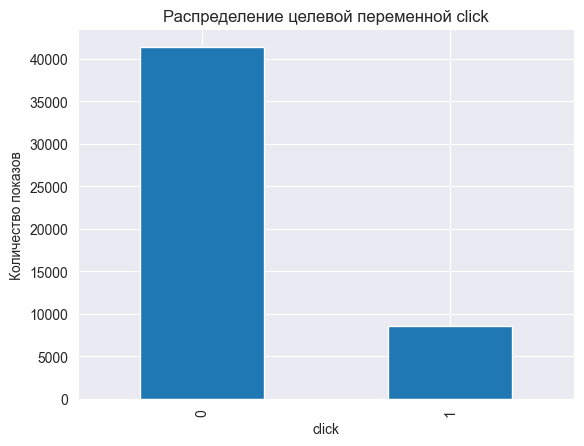

In [9]:
df["click"].value_counts().plot(kind="bar")
plt.title("Распределение целевой переменной click")
plt.xlabel("click")
plt.ylabel("Количество показов")
plt.show()

Целевая переменная `click` — бинарная:
- `1` — был клик по объявлению,
- `0` — клика не было.

Доля кликов составляет около **17.2%**, то есть клики встречаются реже, чем отсутствие клика.
Это означает наличие **дисбаланса классов** (умеренного), поэтому для оценки качества модели основной метрикой будет **PR-AUC**, а для качества вероятностей — **Log Loss** и **Brier score**.

### 2.3 Анализ признаков

In [10]:
# Удаляем id как изначально не информативный признак
df_eda = df.copy()
df_eda.drop(columns=['id'], inplace=True)

In [11]:
# Скрининг site_id, app_id, device_id, device_id
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
cardinality = df_eda[cat_cols].nunique().sort_values(ascending=False)

display(cardinality)

In [12]:
# исключаем devise_ip как почти уникальный признак и device_id
df_eda = df_eda.drop(columns=['device_ip'])

На этапе первичного отбора исключены признаки `device_ip` и `device_id`.
`device_ip` имеет крайне высокую кардинальность (почти уникален для большинства наблюдений), что повышает риск переобучения и снижает интерпретируемость модели.
`device_id` также является высококардинальным идентификатором устройства и может приводить к “запоминанию” отдельных устройств вместо выявления общих факторов клика, поэтому он исключён на раннем этапе.

In [13]:
# Уникальные значения по всем признакам
uniq = pd.DataFrame({
    "dtype": df_eda.dtypes.astype(str),
    "n_unique": df_eda.nunique(dropna=False),
    "unique_share": (df_eda.nunique(dropna=False) / len(df_eda)).round(4)
}).sort_values("n_unique", ascending=False)

display(uniq)

In [14]:
num_cols = df_eda.select_dtypes(exclude=["object", "string"]).columns
display(uniq.loc[num_cols].sort_values("n_unique", ascending=False))

В датасете представлены две основные группы признаков:

**Категориальные признаки (строковые, dtype = object/string):**
- Площадка: `site_id`, `site_domain`, `site_category`
- Приложение: `app_id`, `app_domain`, `app_category`
- Устройство: `device_id`, `device_ip`, `device_model`
- ML-категории: `ml_feature_2`, `ml_feature_7`

**Числовые признаки (dtype = int/float):**
- Время/контекст: `hour`, `banner_pos`, `C1`
- Дискретные/анонимизированные: `C14–C21`, `device_type`, `device_conn_type`, `ml_feature_4`
- Непрерывные ML-признаки: `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10`

**Явно бесполезные/технические признаки:**
- `id` — уникальный идентификатор записи о показе, не несёт информации о вероятности клика и может приводить к переобучению, поэтому удалён.
- `device_ip`— высококардинальные идентификаторы устройства/пользователя. Такие признаки могут снижать интерпретируемость и повышать риск переобучения, поэтому исключены на этапе первичного отбора (решение обосновано высокой кардинальностью).

### 2.4 Анализ пропущенных значений

In [15]:
# Анализ пропущенных значений:
# Доля пропусков по каждому признаку
missing_share = df_eda.isna().mean().sort_values(ascending=False)

display(missing_share[missing_share > 0])
print(f"Всего признаков с пропусками: {(missing_share > 0).sum()} из {df_eda.shape[1]}")

In [16]:
# Анализ категориальных признаков на заглушки
cat_cols = df_eda.select_dtypes(include=["object", "string"]).columns

placeholder_tokens = {"", "unknown", "unk", "none", "null", "na", "n/a", "nan", "missing", "?", "-", "(not set)"}

def placeholder_share(s: pd.Series) -> float:
    # приводим к строке, чистим пробелы и нижний регистр
    x = s.astype(str).str.strip().str.lower()
    return x.isin(placeholder_tokens).mean()

placeholder_stats = (
    pd.Series({col: placeholder_share(df_eda[col]) for col in cat_cols})
    .sort_values(ascending=False)
)

display(placeholder_stats[placeholder_stats > 0])

In [17]:
# Анализ числовых признаков на заглушки в данных
num_cols = df_eda.select_dtypes(exclude=["object", "string"]).columns

# Частота 0 и -1 для каждого числового признака
zero_share = (df_eda[num_cols] == 0).mean().sort_values(ascending=False)
minus1_share = (df_eda[num_cols] == -1).mean().sort_values(ascending=False)

print("Топ признаков по доле нулей:")
display(zero_share.head(15))

print("Топ признаков по доле -1:")
display(minus1_share[minus1_share > 0].head(15))

In [18]:
# Смотрим на вывод первых десяти строк device_conn_type
df_eda['device_conn_type'].head(10)

In [19]:
# Изучаем распределение данных по уникальным категориям device_conn_type
df_eda["device_conn_type"].value_counts().sort_index()

Признак `device_conn_type` представлен числовыми кодами и имеет 4 уникальных значения: 0, 2, 3 и 5. Наиболее частое значение — 0 (около 86% наблюдений), что может соответствовать доминирующей категории либо «unknown/other» в анонимизированных данных. Поскольку признак является категориальным по смыслу (непрерывного порядка нет), на этапе предобработки он будет обрабатываться как категориальный и кодироваться (например, One-Hot Encoding).

In [20]:
df["banner_pos"].value_counts(dropna=False).sort_index()

In [21]:
df['device_type'].value_counts(dropna=False).sort_index()

Признаки `device_type`, `device_conn_type` и `banner_pos` имеют тип int, однако содержат небольшое число уникальных кодов, то есть по смыслу являются категориальными. Поэтому на этапе предобработки они будут рассматриваться как категориальные и кодироваться (например, One-Hot Encoding), чтобы модель не интерпретировала коды как числовую шкалу.

Также у `banner_pos` обнаружены редкие значения (2, 3, 4, 5, 7 встречаются крайне редко), поэтому на этапе подготовки признаков возможно объединение редких категорий в группу `other`.

### 2.5 Анализ категориальных признаков

In [22]:
cat_str_cols = df_eda.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

TARGET_COL = "click"
OHE_THRESHOLD = 100

# явные кодовые категории (int, но по смыслу категориальные)
coded_cols = ["banner_pos", "device_type", "device_conn_type", "C1"] + [f"C{i}" for i in range(14, 22)]
coded_cols = [c for c in coded_cols if c in df_eda.columns]

# Обьедеиняем и страхуемся от дубликатов (просто не уверен, что правильно перебрал)
cat_cols = []
for col in (cat_str_cols + coded_cols):
    cat_cols.append(col)

print("Категориальные признаки:", len(cat_cols))
print(cat_cols)

cat_cardinality = df_eda[cat_cols].nunique().sort_values(ascending=False)
display(cat_cardinality)


In [23]:
# деление под типы кодирования
ohe_cols = cat_cardinality[cat_cardinality <= OHE_THRESHOLD].index.tolist()
high_card_cols = cat_cardinality[cat_cardinality > OHE_THRESHOLD].index.tolist()

print("OHE признаки (<= 100 уникальных):", len(ohe_cols))
print(ohe_cols)

print("\nHigh-card признаки (> 100 уникальных):", len(high_card_cols))
print(high_card_cols)

In [24]:
# Задаём функцию для визуализации рапределения
def plot_group_grid(df, cols, title, top_n=None):

    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols  # ceil без math

    fig = plt.figure(figsize=(4*n_cols, 3*n_rows))
    fig.suptitle(title, fontsize=14)

    for i, col in enumerate(cols, start=1):
        vc = df[col].value_counts()

        if top_n and len(vc) > top_n:
            vc = pd.concat([vc.head(top_n), pd.Series({"OTHER": vc.iloc[top_n:].sum()})])

        ax = fig.add_subplot(n_rows, n_cols, i)
        ax.bar(vc.index.astype(str), vc.values)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

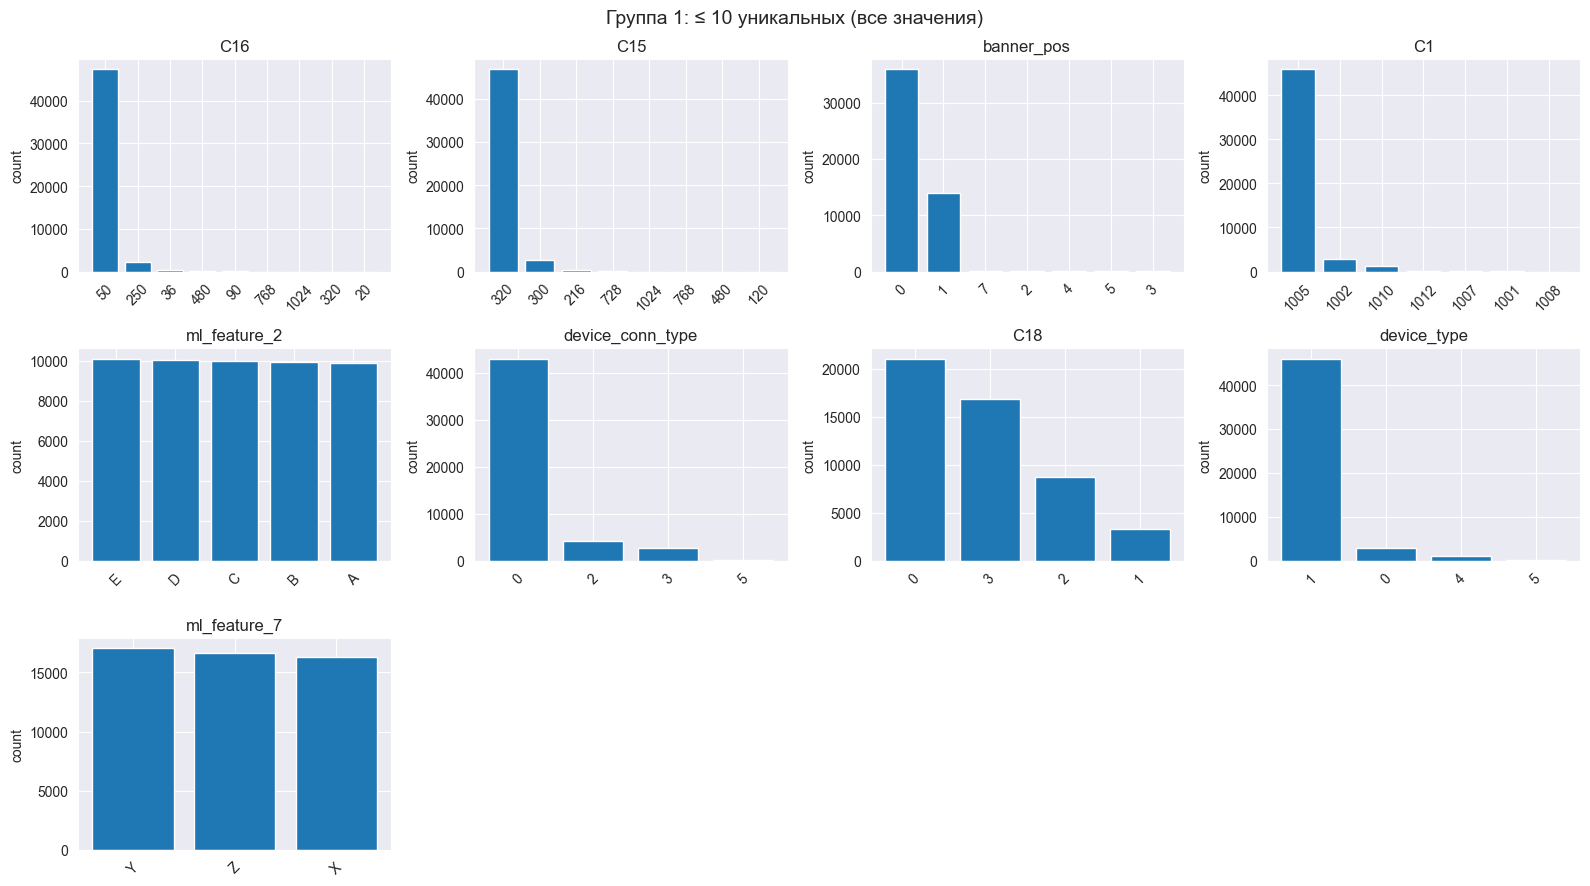

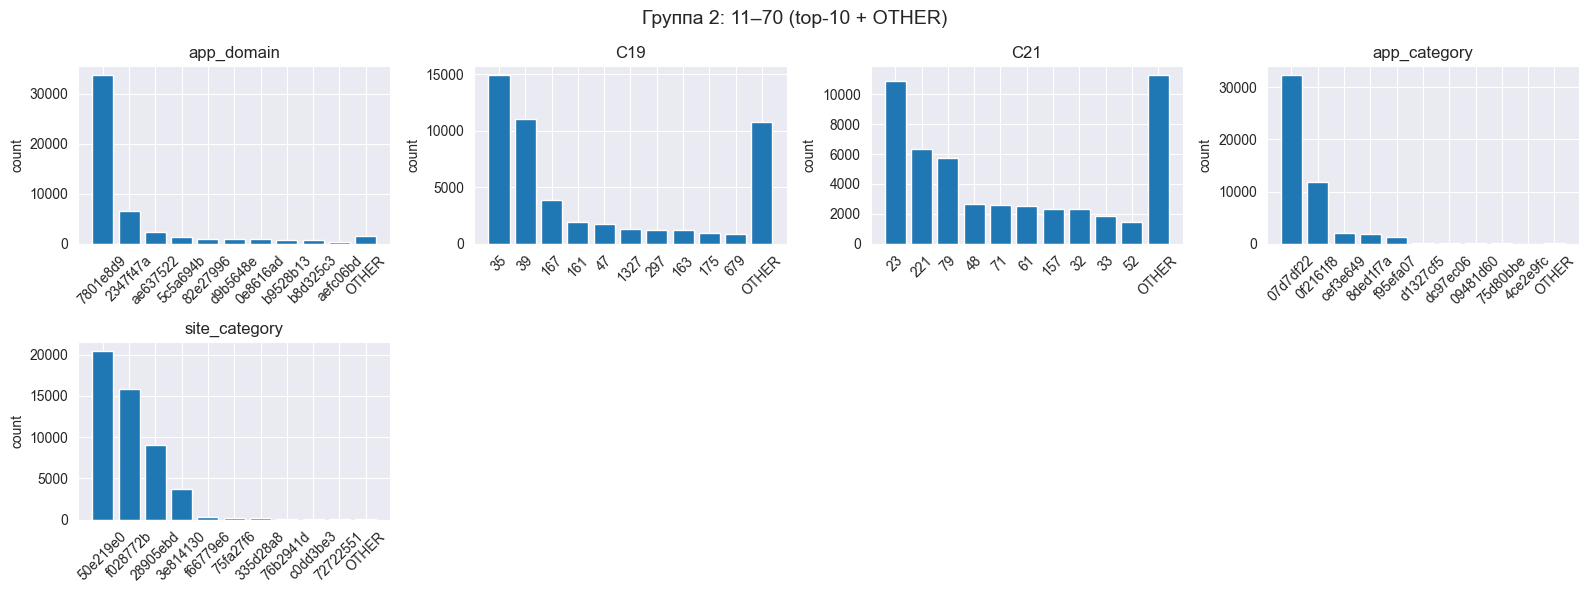

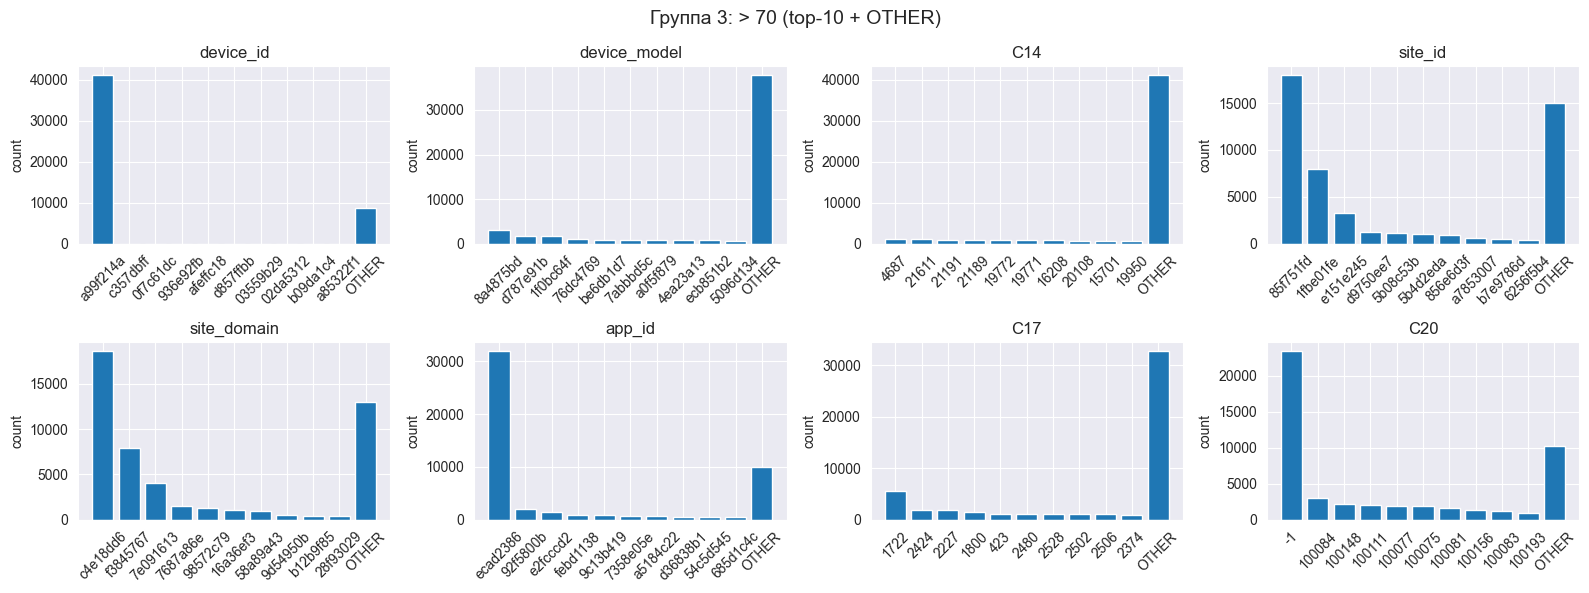

In [25]:
# Группировка по кардинальности
group_1 = cat_cardinality[cat_cardinality <= 10].index.tolist()
group_2 = cat_cardinality[(cat_cardinality > 10) & (cat_cardinality <= 70)].index.tolist()
group_3 = cat_cardinality[cat_cardinality > 70].index.tolist()

plot_group_grid(df_eda, group_1, "Группа 1: ≤ 10 уникальных (все значения)")
plot_group_grid(df_eda, group_2, "Группа 2: 11–70 (top-10 + OTHER)", top_n=10)
plot_group_grid(df_eda, group_3, "Группа 3: > 70 (top-10 + OTHER)", top_n=10)

In [26]:
# Отдельная проверка device_id
vc = df_eda["device_id"].value_counts()
top1_share = vc.iloc[0] / len(df_eda)
top10_share = vc.head(10).sum() / len(df_eda)

print("Уникальных device_id:", vc.shape[0])
print("Топ-1 device_id:", vc.index[0], "count:", vc.iloc[0], f"share: {top1_share:.2%}")
print("Сумма топ-10 share:", f"{top10_share:.2%}")
print("OTHER share (всё остальное):", f"{1 - top10_share:.2%}")

In [27]:
# Удаляем device_id
df_eda = df_eda.drop(columns=["device_id"])

In [28]:
# Отдельная проверка app_id
vc = df_eda["app_id"].value_counts()
top1_share = vc.iloc[0] / len(df_eda)
top10_share = vc.head(10).sum() / len(df_eda)

print("Уникальных app_id:", vc.shape[0])
print("Топ-1 app_id:", vc.index[0], "count:", vc.iloc[0], f"share: {top1_share:.2%}")
print("Сумма топ-10 share:", f"{top10_share:.2%}")
print("OTHER share (всё остальное):", f"{1 - top10_share:.2%}")

Для `app_id` обнаружено сильно скошенное распределение: одно приложение составляет ~64% всех показов. В отличие от `device_id`, этот признак отражает бизнес-сущность (рекламируемое приложение) и потенциально является важным фактором CTR. Чтобы снизить риск переобучения на редких категориях, значения `app_id` будут сгруппированы: сохраняются top-N наиболее частых приложений, остальные объединяются в категорию `OTHER_APP`. Далее признак кодируется (OHE либо Target Encoding в пайплайне).

#### Вывод по 2.5 (категориальные признаки и способы кодирования)

Для категориальных признаков рассчитана кардинальность и построены распределения частот (для признаков с большим числом категорий показан top-10 и агрегированная категория OTHER).

**Группа 1 (< 10 уникальных):** `C16`, `C15`, `banner_pos`, `C1`, `ml_feature_2`, `device_conn_type`, `C18`, `device_type`, `ml_feature_7`.
Эти признаки имеют малую кардинальность и могут быть закодированы с помощью **One-Hot Encoding** без существенного разрастания пространства признаков.

**Группа 2 (11–70 уникальных):** `app_domain`, `C19`, `C21`, `app_category`, `site_category`.
Кардинальность умеренная: также подходит **One-Hot Encoding**, при этом на графиках видно, что распределения часто скошены (несколько популярных категорий и длинный хвост редких).

**Группа 3 (> 70 уникальных):** `device_id`, `device_model`, `C14`, `site_id`, `site_domain`, `app_id`, `C17`, `C20`.
Эти признаки обладают высокой кардинальностью: применение OHE приведёт к большому числу разреженных признаков, поэтому для них потребуются специальные методы кодирования, например **Target Encoding** (как указано в ТЗ), реализованный внутри пайплайна, чтобы избежать утечки данных.

Итоговое решение по способу кодирования:
- **OHE:** 14 признаков (`app_domain`, `C19`, `C21`, `app_category`, `site_category`, `C16`, `C15`, `banner_pos`, `C1`, `ml_feature_2`, `device_conn_type`, `C18`, `device_type`, `ml_feature_7`);
- **High-card encoding (Target Encoding):** 8 признаков (`device_model`, `C14`, `site_id`, `site_domain`, `app_id`, `C17`, `C20`).

Дополнительно по распределениям видно, что для многих high-card признаков значительная доля наблюдений относится к категории OTHER, что подтверждает наличие большого числа редких значений и необходимость специальных методов кодирования вместо OHE.

Дополнительно проведена проверка распределения `device_id`. Обнаружено, что одно значение встречается в 82.4% наблюдений, что указывает на технический/дефолтный идентификатор и создаёт риск переобучения. Для повышения устойчивости и интерпретируемости модели признак `device_id` исключён из дальнейшего анализа и моделирования.

### 2.6 Анализ выбросов и распределений

In [29]:
# Преобразуем hour в категорию
df_eda = df_eda.copy()

df_eda["hour"] = pd.to_datetime(df_eda["hour"].astype(str), format="%y%m%d%H", errors="coerce")
df_eda["hour_of_day"] = df_eda["hour"].dt.hour.astype("category")
df_eda["dayofweek"] = df_eda["hour"].dt.dayofweek.astype("category")

df_eda = df_eda.drop(columns=["hour"])

# Выводим числовые признаки
num_cols = df_eda.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in num_cols if c != "click"]
print("Числовых признаков:", len(num_cols))
print(num_cols)

In [30]:
# Выыодим статистики по числовым признакам
display(df_eda[num_cols].describe())

In [31]:
# Строим забор Тьюки:
def outlier_share_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((s < low) | (s > high)).mean()

outlier_stats = pd.DataFrame({
    "dtype": df_eda[num_cols].dtypes.astype(str),
    "n_unique": df_eda[num_cols].nunique(),
    "outlier_share_iqr": df_eda[num_cols].apply(outlier_share_iqr),
    "skew": df_eda[num_cols].skew(numeric_only=True)
}).sort_values("outlier_share_iqr", ascending=False)

display(outlier_stats)

- Самые "проблемные" по IQR-выбросам: C19, затем C17, C14.
- Много признаков имеют outlier_share_iqr = 0, но это не значит "выбросов нет вообще" — часто это значит, что признак дискретный/категориальный, и IQR-правило для него малоинформативно.

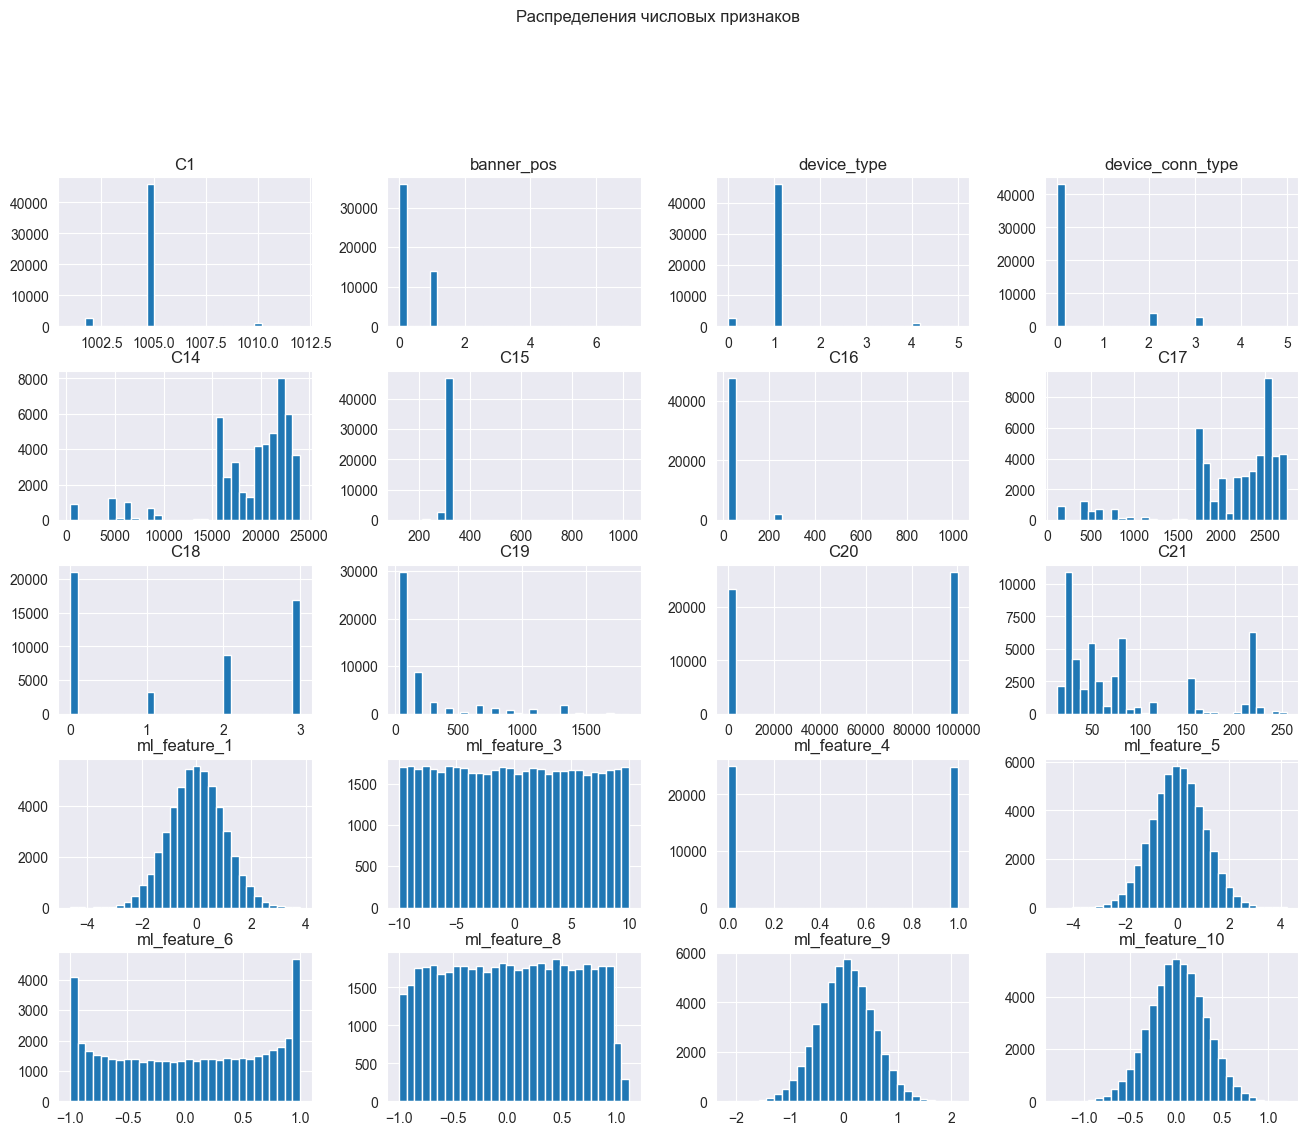

In [32]:
# Визуализация распределения числовых признаков
df_eda[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Распределения числовых признаков", y=1.02)
plt.show()

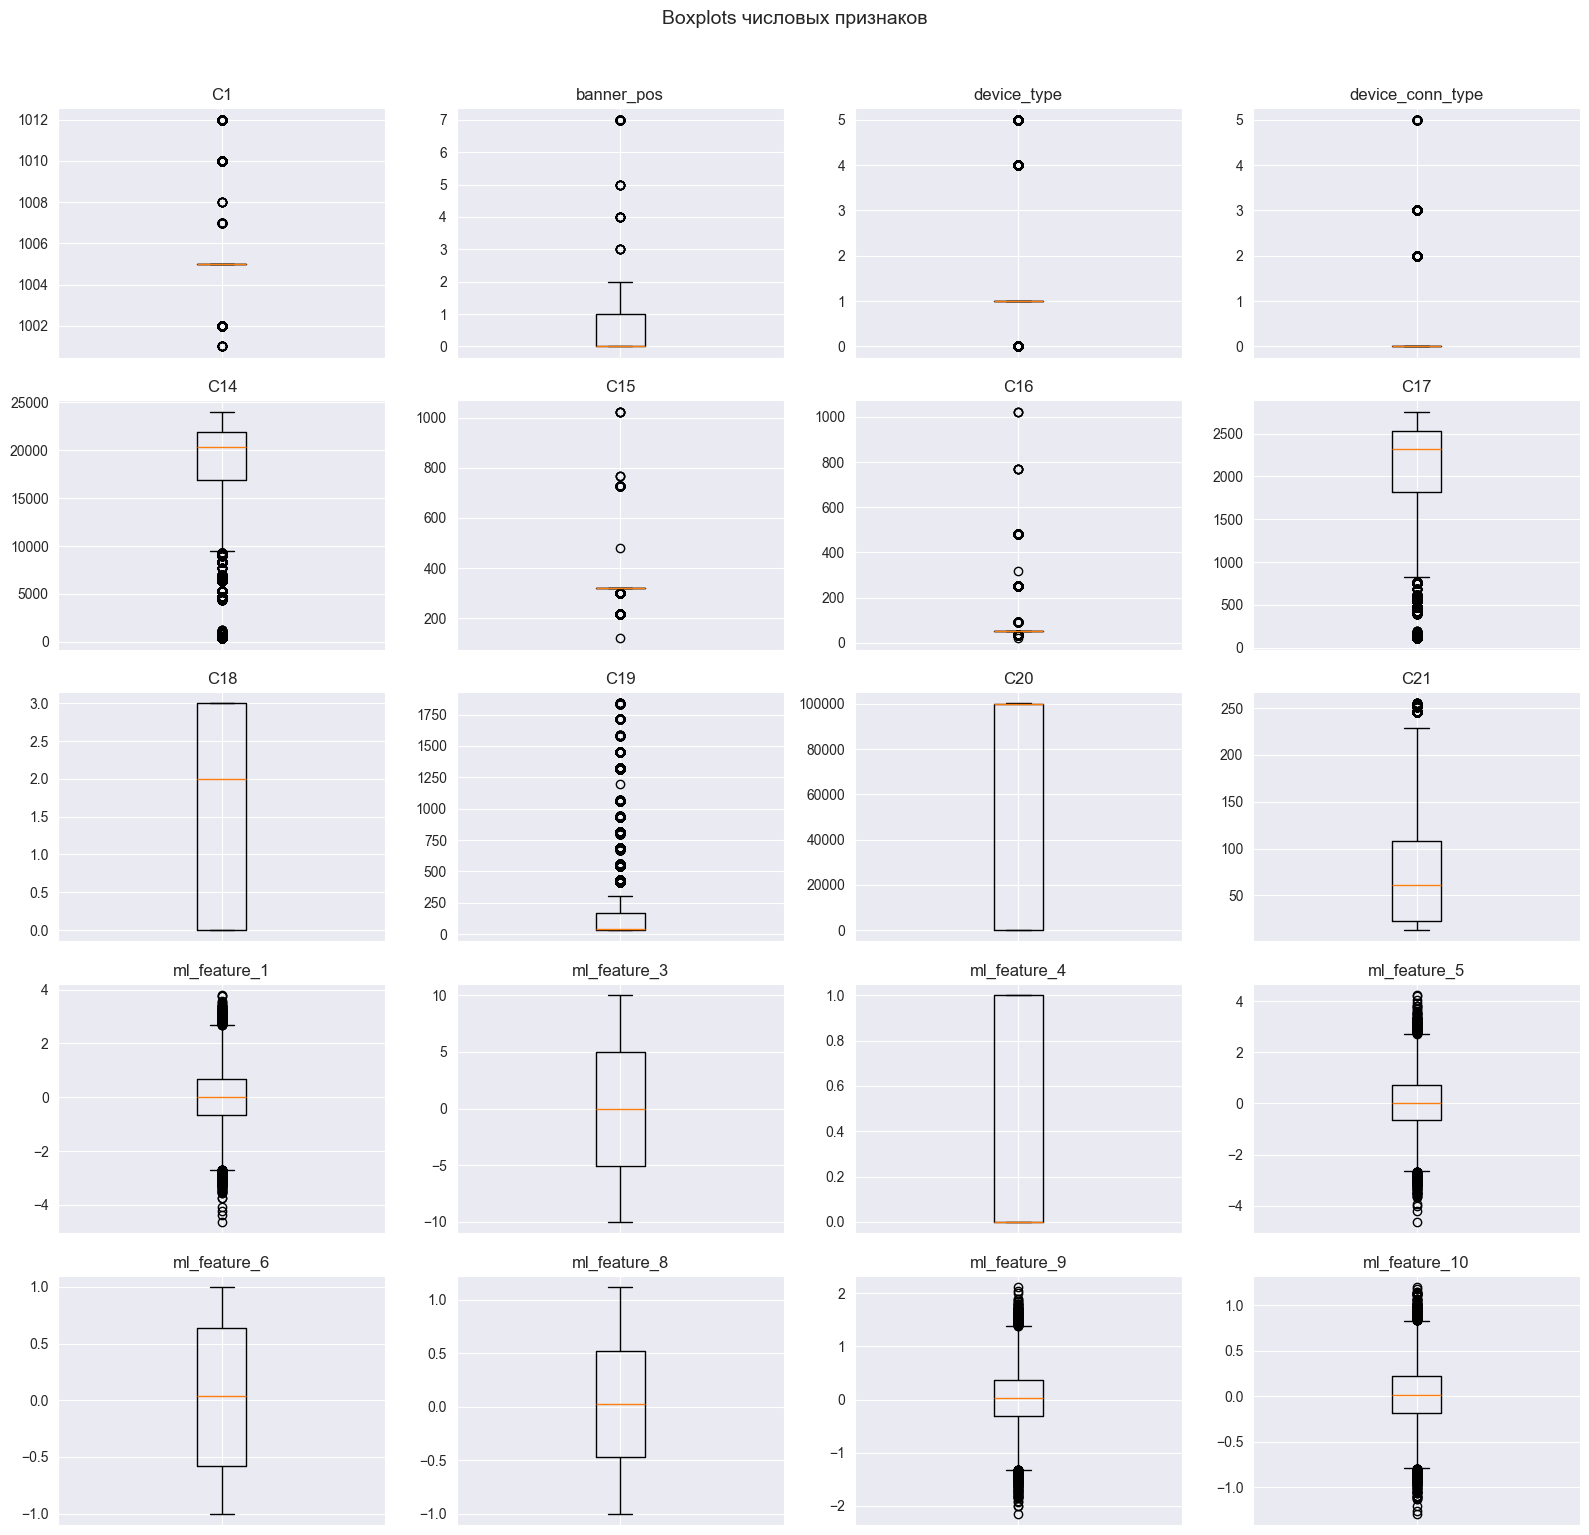

In [33]:
# Строим боксплот для числовых признаков
cols = num_cols

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_eda[col], vert=True)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", labelbottom=False)

# убираем пустые ячейки
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Вывод по 2.6 (выбросы и распределения)

По гистограммам и boxplot видно, что числовые признаки неоднородны по своей природе:

- **ML-признаки (`ml_feature_*`)** имеют ограниченные шкалы и в целом близкие к симметричным распределения. Для части признаков наблюдаются отдельные крайние значения, однако их доля невелика (по IQR < 1%), что не указывает на серьёзные аномалии данных.
- **Кодовые дискретные признаки** (`banner_pos`, `device_type`, `device_conn_type`, `C1`, `C14–C21`) не являются непрерывными величинами, поэтому нормального распределения для них не ожидается. Для `C14`, `C17`, `C19` заметны выраженные хвосты и большое число редких значений, что отражается в повышенной доле «выбросов» по правилу IQR (это скорее редкие категории/коды, а не ошибки).
- В `C20` присутствует значение `-1`, которое выглядит как специальный код/заглушка (например, unknown), поэтому требует отдельной обработки на этапе предобработки, а не удаления как выброса.

На данном этапе выбросы не удаляются вручную: для кодовых признаков это, вероятно, редкие значения, а для ML-признаков данные выглядят согласованно со шкалами признаков. При необходимости обработка крайних значений будет рассматриваться позже по влиянию на качество и калибровку модели.

### 2.7 Корреляции

In [34]:
TARGET_COL = "click"

# копия для корреляции
df_corr = df_eda.copy()

# список колонок, которые считаем категориальными по смыслу
coded_as_cat = ["banner_pos", "device_type", "device_conn_type", "C1"] + [f"C{i}" for i in range(14, 22)]
coded_as_cat = [c for c in coded_as_cat if c in df_corr.columns]

# + строковые колонки и ml_feature_2/ml_feature_7 уже строковые
for c in coded_as_cat:
    df_corr[c] = df_corr[c].astype('category')

# на всякий случай проверим, что target бинарный int
df_corr[TARGET_COL] = df_corr[TARGET_COL].astype(int)
# считаем phik-корреляции
phik_matrix = df_corr.phik_matrix(interval_cols=None)
display(phik_matrix)

In [35]:
# Какие признаки сильнее всего связаны с click
target_corr = phik_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
display(target_corr.head(20))

print("Топ-10 признаков по PhiK с click:")
print(target_corr.head(10))

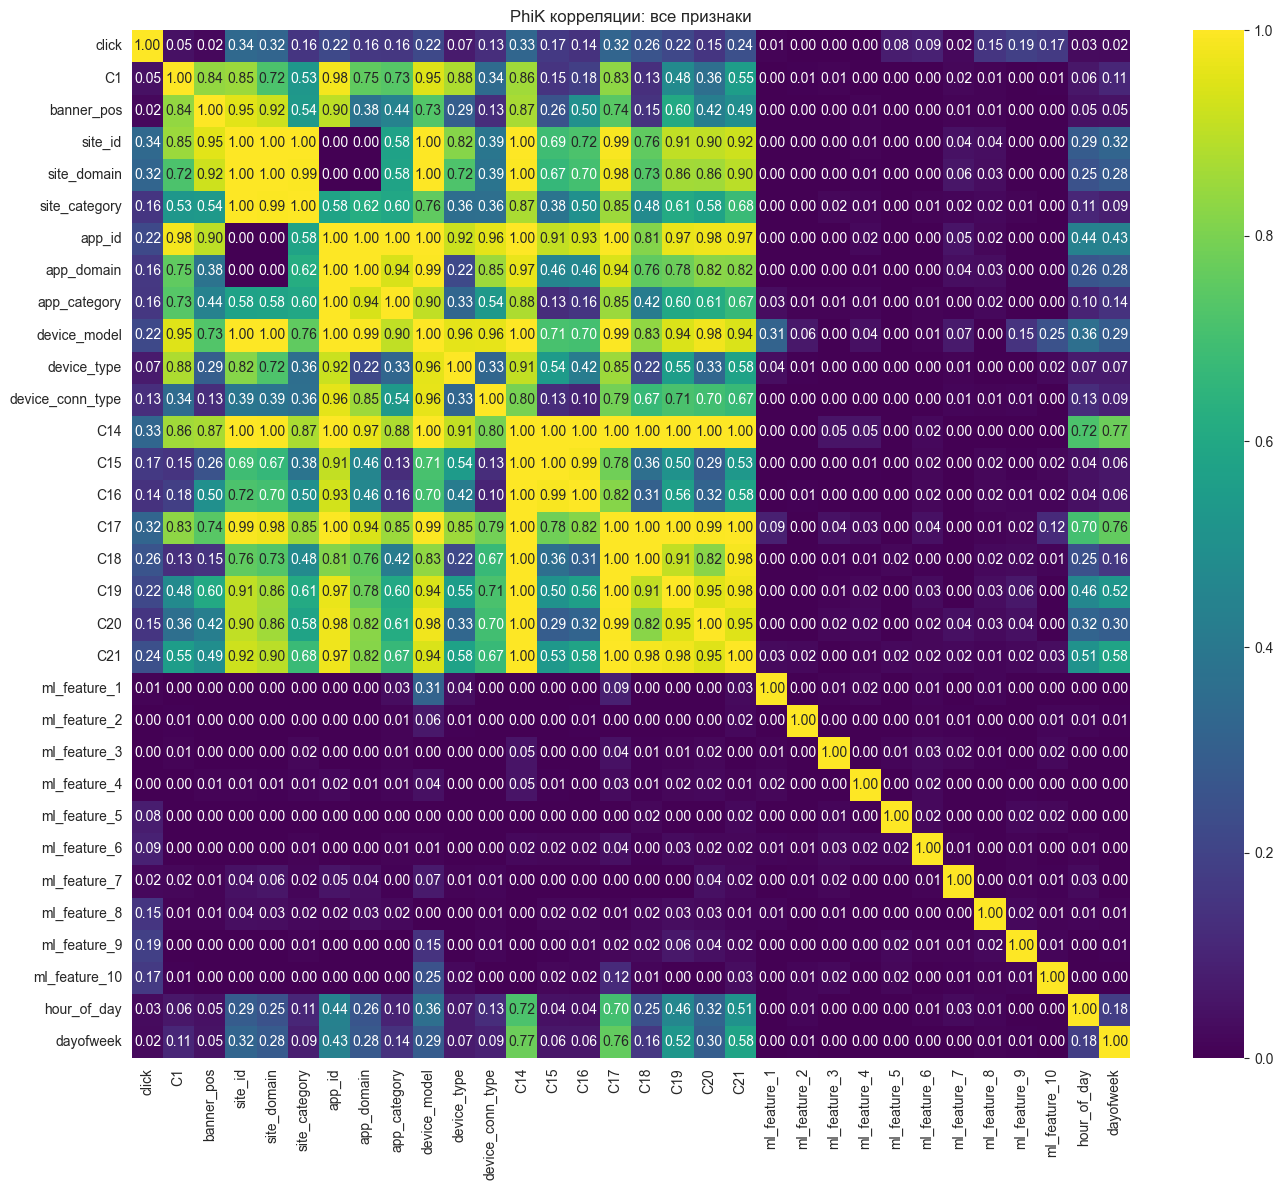

In [36]:
# Строим heatmap seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title("PhiK корреляции: все признаки")
plt.tight_layout()
plt.show()

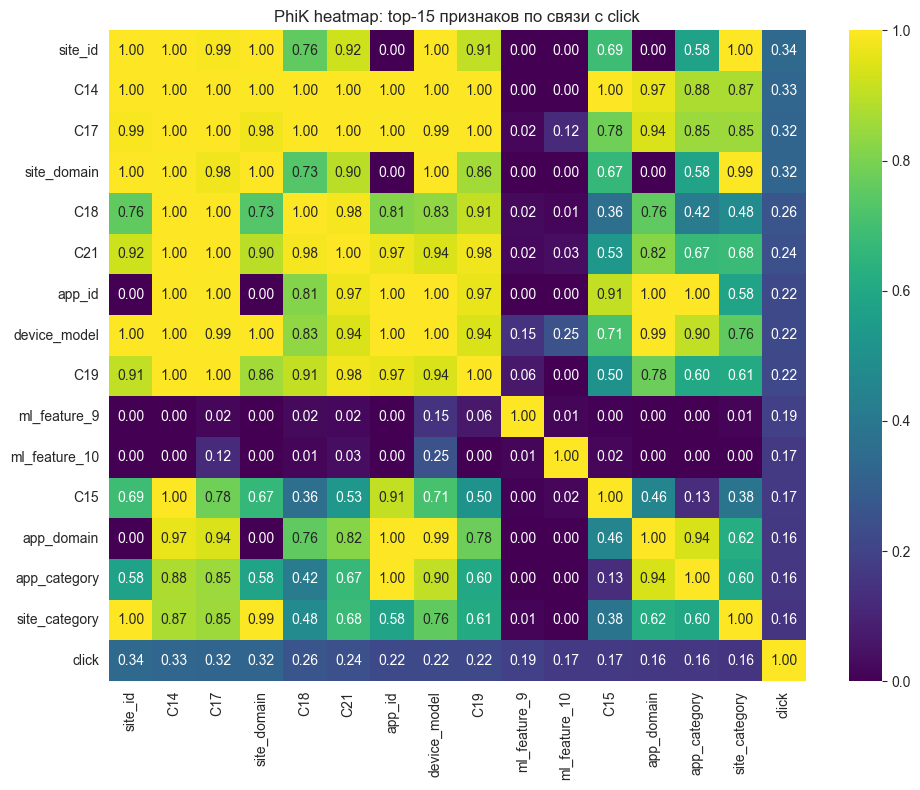

In [37]:
# Heatmap top-N признаков по связи с click
TOP_N = 15

top_feats = target_corr.head(TOP_N).index.tolist()
cols = top_feats + [TARGET_COL]

plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix.loc[cols, cols], vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title(f"PhiK heatmap: top-{TOP_N} признаков по связи с {TARGET_COL}")
plt.tight_layout()
plt.show()

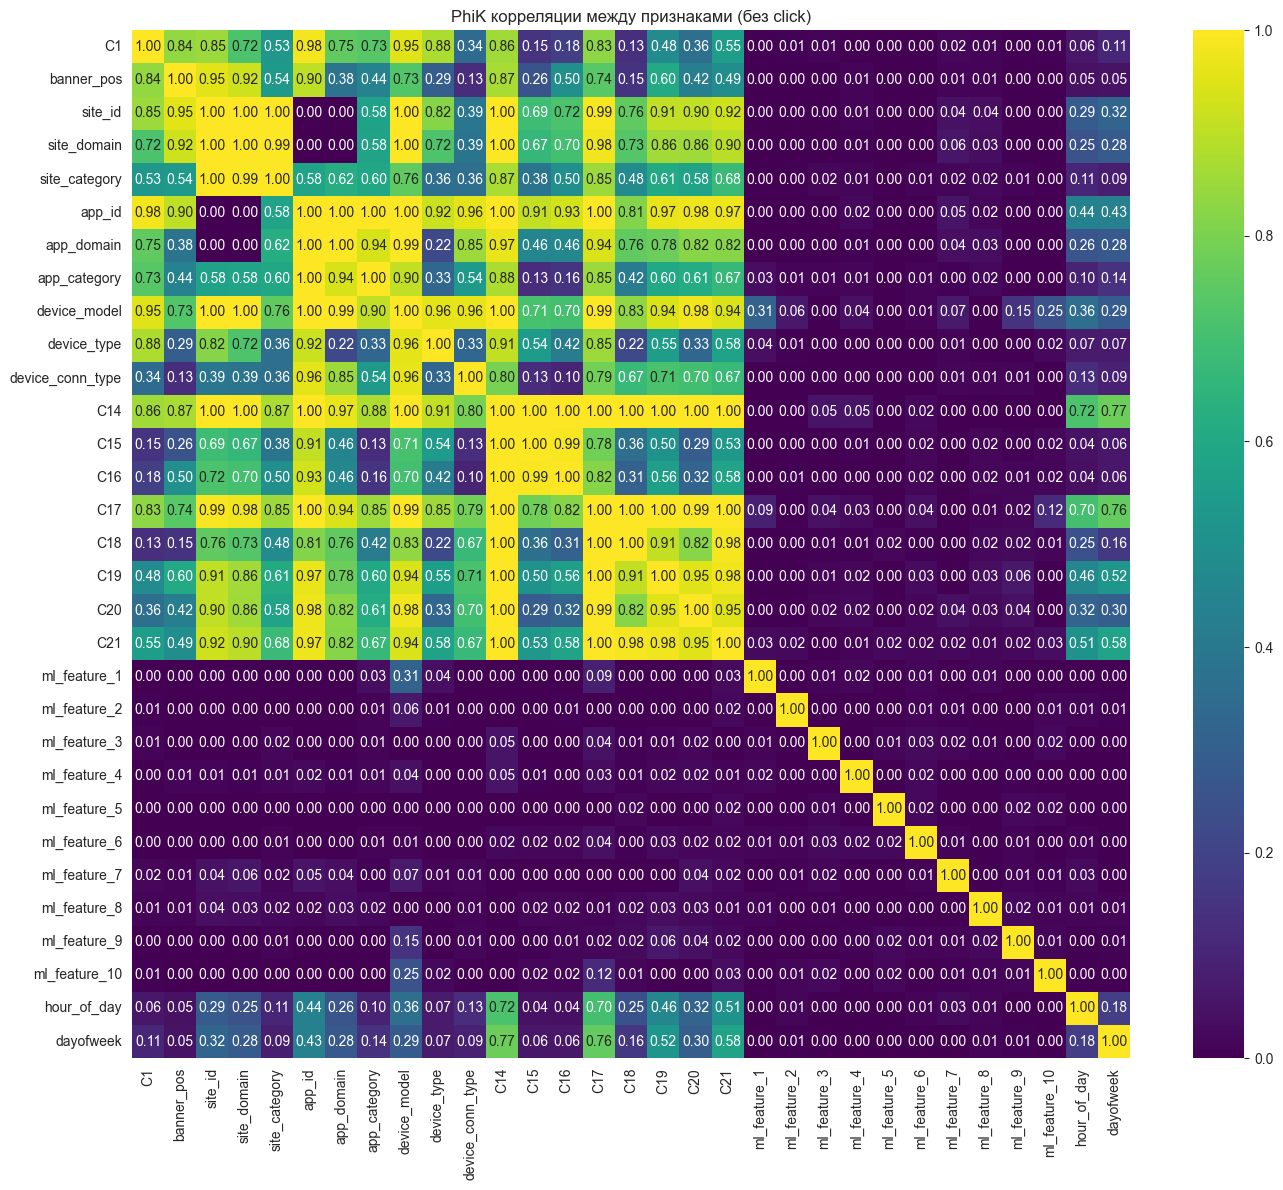

In [38]:
# Heatmap только “фича-фича” (без click)
feat = phik_matrix.drop(index=TARGET_COL, columns=TARGET_COL)

plt.figure(figsize=(14, 12))
sns.heatmap(feat, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title("PhiK корреляции между признаками (без click)")
plt.tight_layout()
plt.show()

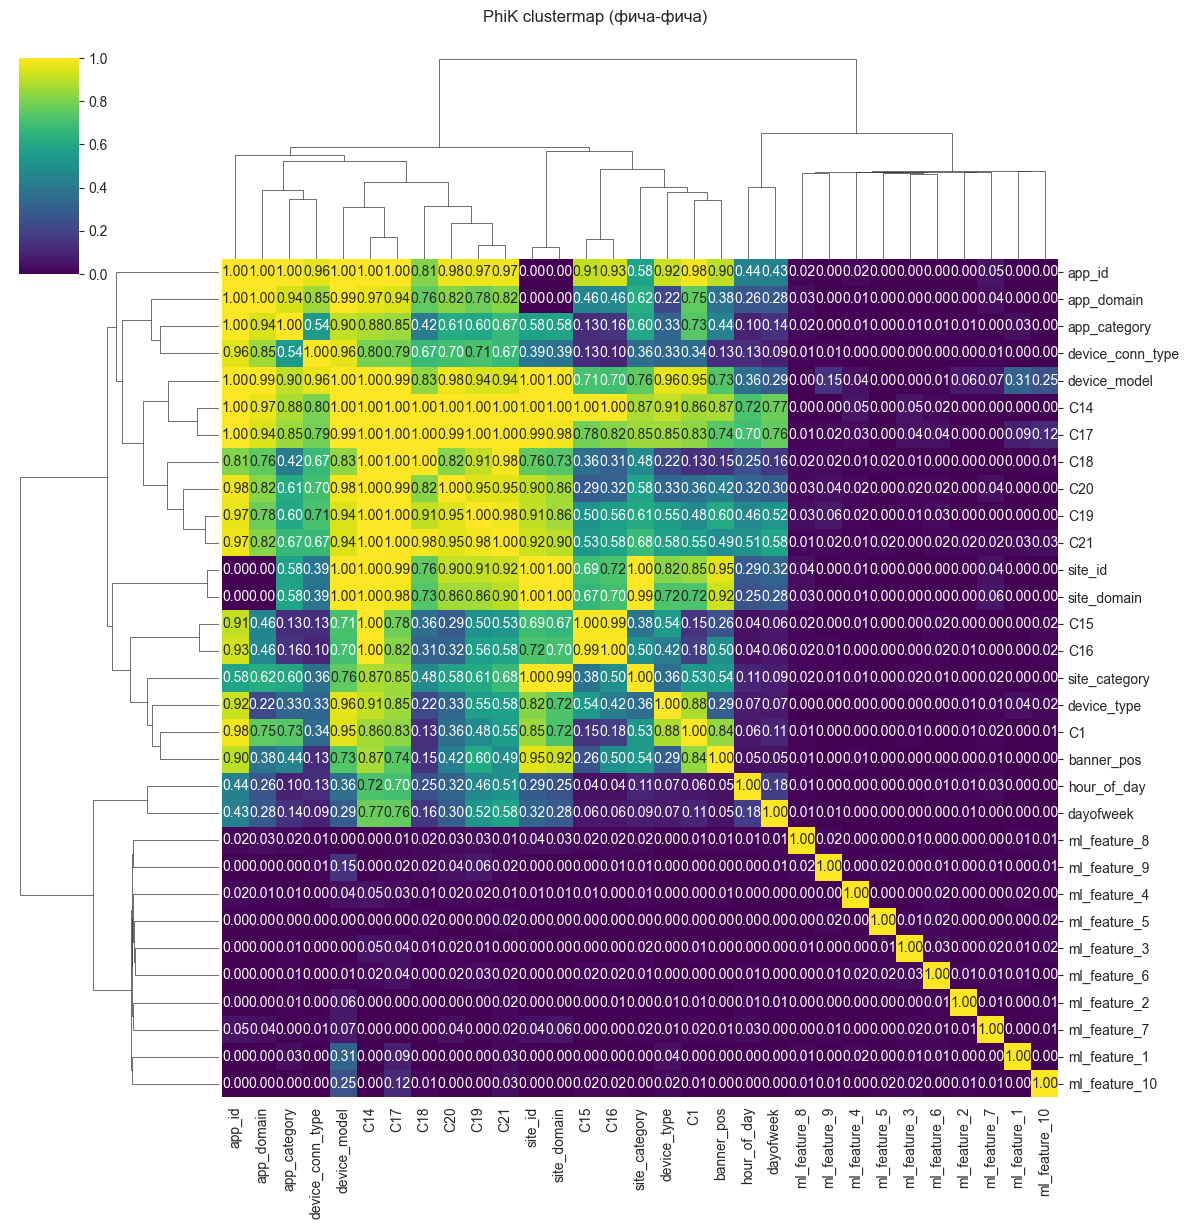

In [39]:
# clustermap (группирует похожие признаки)
sns.clustermap(
    phik_matrix.drop(index=TARGET_COL, columns=TARGET_COL),
    cmap="viridis",
    vmin=0, vmax=1,
    figsize=(12, 12),
    annot=True, fmt=".2f"
)
plt.suptitle("PhiK clustermap (фича-фича)", y=1.02)
plt.show()

In [40]:
# выводим топ 30 самых сильных корреляций между признаками
FEATURE_CORR_THRESHOLD = 0.80

feat = phik_matrix.drop(index=TARGET_COL, columns=TARGET_COL)

pairs = (
    feat.where(np.triu(np.ones(feat.shape), 1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)
pairs = pairs[pairs >= FEATURE_CORR_THRESHOLD]

print("Пар с PhiK >= ", FEATURE_CORR_THRESHOLD, ":", len(pairs))
display(pairs.reset_index(name="phik").rename(columns={"level_0":"feature_1","level_1":"feature_2"}).head(30))

In [41]:
display(df_eda['site_category'].value_counts())

In [42]:
display(df_eda['site_domain'].value_counts())
rate = (df_eda['site_domain'].value_counts() <=10).sum() / df_eda['site_domain'].nunique()
print(round(rate, 2))
vc = df_eda["site_domain"].value_counts()
rare_row_share = vc[vc <= 10].sum() / len(df_eda)
print("Доля строк с редкими доменами (<=10):", f"{rare_row_share:.2%}")
top10_row_share = vc.head(10).sum() / len(df_eda)
print("Доля строк в топ-10 доменов:", f"{top10_row_share:.2%}")

In [43]:
df_eda['app_domain'].value_counts()
df_eda['app_category'].value_counts()

In [44]:
# Исключаем признаки которые практически дублируют друг друга
drop_cols = ["site_id", "site_category", "app_id", "app_category", "C15", "C16", "C18", "C19", "C20", "C21"]

df_eda_final = df_eda.drop(columns=drop_cols, errors="ignore").copy()
print("Осталось признаков:", df_eda_final.shape[1])
print("Колонки:", df_eda_final.columns.tolist())

In [46]:
# Считаем фик для нового набора признаков
df_corr2 = df_eda_final.copy()

# Явно укажем числовые (интервальные) колонки: ml_feature_* (кроме строковых ml_feature_2/ml_feature_7)
interval_cols = [c for c in df_corr2.columns if c.startswith("ml_feature_") and c not in ["ml_feature_2", "ml_feature_7"]]

# считаем PhiK
phik_matrix2 = df_corr2.phik_matrix(interval_cols=interval_cols)

# PhiK с таргетом
target_corr2 = phik_matrix2[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
display(target_corr2.head(20))

#### Вывод корреляции (PhiK)

Для оценки связи признаков с целевой переменной и между собой использована **PhiK-корреляция**, так как в данных присутствуют как числовые, так и категориальные/кодовые признаки (например `C*`, `device_type`, `banner_pos`). PhiK корректно работает со смешанными типами данных и позволяет сравнивать зависимости в единой шкале.

#### Связь признаков с целевой переменной `click`
По значениям PhiK наиболее информативными для предсказания клика оказались:
- **`C14` (~0.33) и `C17` (~0.32)** — сильнейшие признаки среди группы `C14–C21`;
- **`site_domain` (~0.32)** — характеристика площадки показа даёт заметный вклад в CTR;
- **`device_model` (~0.22)** — модель устройства связана с вероятностью клика;
- из числовых ML-признаков наиболее выраженный сигнал дают **`ml_feature_9` (~0.19), `ml_feature_10` (~0.17), `ml_feature_8` (~0.15)**;
- признаки времени (`hour_of_day`, `dayofweek`) и позиции (`banner_pos`) демонстрируют **слабую связь** с таргетом (PhiK порядка 0.02–0.03), но могут быть полезны в комбинации с другими факторами.

В целом значения PhiK с `click` находятся в умеренном диапазоне (до ~0.33), что типично для задач CTR: вероятность клика зависит от множества факторов, и максимальный эффект обычно достигается за счёт их совместного использования в модели.

#### Корреляции между признаками (feature-feature) и мультиколлинеарность
По heatmap PhiK обнаружены группы признаков с **очень высокой взаимной зависимостью (PhiK ≈ 1)**, что указывает на дублирование информации и потенциальную мультиколлинеарность:
- в блоке **Site** признаки `site_id`, `site_domain`, `site_category` практически дублируют друг друга;
- в блоке **App** признаки `app_id`, `app_domain`, `app_category` также сильно взаимосвязаны;
- внутри группы **`C14–C21`** наблюдается высокая избыточность: многие признаки тесно коррелируют друг с другом.

Использование всех таких признаков одновременно может ухудшать интерпретируемость, увеличивать размерность и делать коэффициенты линейных моделей менее стабильными.

#### Принятое решение по первичному отбору признаков
Для снижения избыточности и сохранения информативности выполнен первичный отбор:
- **Site:** оставлен `site_domain`, удалены `site_id`, `site_category`;
- **App:** оставлен `app_domain`, удалены `app_id`, `app_category`;
- **C14–C21:** оставлены наиболее связанные с `click` признаки `C14` и `C17`, остальные удалены как дублирующие.

Признаки `site_domain` и `app_domain` имеют высокую кардинальность, поэтому на этапе моделирования будут кодироваться методом **Target Encoding** (внутри пайплайна и с предотвращением утечек через кросс-валидацию).

### 2.8 Выводы по EDA

#### Ключевые находки
- Датасет содержит **50 000 наблюдений** и признаки, описывающие площадку показа (Site), рекламируемое приложение (App), устройство пользователя, а также набор анонимизированных признаков `C*` и машинно-сгенерированные `ml_feature_*`.
- Целевая переменная **несбалансирована**: доля кликов составляет около **17%**, поэтому при обучении и оценке качества важно использовать метрики, устойчивые к дисбалансу (в проекте — PR-AUC, LogLoss и Brier Score).
- Явных пропусков (`NaN`) в данных не обнаружено, однако выявлены потенциальные «заглушки» в кодовых признаках (например, значение **-1** в `C20` встречается очень часто), что следует учитывать как отдельную категорию/значение.
- Анализ PhiK-корреляций показал наличие **сильной мультиколлинеарности**: в группах Site (`site_id`, `site_domain`, `site_category`), App (`app_id`, `app_domain`, `app_category`) и внутри `C14-C21` многие признаки практически дублируют друг друга (PhiK~1). Поэтому выполнен первичный отбор и удаление избыточных признаков.

#### Наиболее перспективные признаки для модели
Выбор основан на PhiK-корреляции с `click` и бизнес-смысле:
- **`C14`, `C17`** — наиболее сильные признаки из блока `C14-C21` (наиболее высокая связь с `click`), при этом остальные признаки группы преимущественно избыточны.
- **`site_domain`, `app_domain`** — ключевые признаки, отражающие контекст площадки/приложения показа; демонстрируют заметную связь с кликом.
- **`device_model`, `device_type`, `device_conn_type`** — признаки устройства и соединения, влияющие на пользовательское поведение и вероятность клика.
- **`ml_feature_8`, `ml_feature_9`, `ml_feature_10`** (а также часть других `ml_feature_*`) — числовые признаки с ненулевой связью с `click`, вероятно содержащие агрегированный/сгенерированный сигнал.
- **Временные признаки `hour_of_day`, `dayofweek`** — слабее связаны с `click`, но могут давать стабильное улучшение в комбинации с контекстными признаками.

Также для снижения избыточности были удалены признаки, которые практически дублируют друг друга:
- из группы Site удалены `site_id`, `site_category` (оставлен `site_domain`);
- из группы App удалены `app_id`, `app_category` (оставлен `app_domain`);
- из `C14-C21` оставлены `C14` и `C17`, остальные удалены.

#### План предобработки перед обучением моделей
1. **Разбиение данных** на train/valid/test (стратифицированно по `click`, фиксируя `random_state`).
2. **Типы признаков:**
   - числовые: `ml_feature_1,3,4,5,6,8,9,10` (при необходимости масштабирование);
   - категориальные: `site_domain`, `app_domain`, `device_model`, `device_type`, `device_conn_type`, `banner_pos`, `C1`, `C14`, `C17`, `ml_feature_2`, `ml_feature_7`, `hour_of_day`, `dayofweek`.
3. **Кодирование категориальных признаков:**
   - для высококардинальных (`site_domain`, `app_domain`, `device_model`, а также `C14`, `C17` при необходимости) использовать **Target Encoding** (внутри пайплайна, с предотвращением утечки через CV);
   - для низкокардинальных (`device_type`, `device_conn_type`, `banner_pos`, `C1`, `ml_feature_2`, `ml_feature_7`, `hour_of_day`, `dayofweek`) использовать **One-Hot Encoding**.
4. **Обработка заглушек/спецзначений** (например, `-1` в `C20` в случае возвращения признака) как отдельной категории или отдельного значения.
5. **Пайплайн** предобработки + модель оформить через `Pipeline`/`ColumnTransformer` для воспроизводимости и исключения утечек.
6. **Baseline-модели:** Logistic Regression и линейный SVM, подбор гиперпараметров через `GridSearchCV`.
7. **Калибровка вероятностей:** построение calibration curve и изотоническая калибровка; сравнение по Brier score и графикам.

### 3. Разделение данных на выборки
- Сначала отделим тестовую выборку 20% данных.
- Оставшиеся 80% данных используем для обучения.
- Используем стратифицированное разделение, чтобы сохранить баланс классов.

In [47]:
# разделение выборки
RANDOM_STATE = 42

X = df_eda_final.drop(columns=['click'])
y = df_eda_final['click']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=RANDOM_STATE)

X_train, X_calib, y_train, y_calib = train_test_split(X_train_full, y_train_full, test_size=0.3, shuffle=True, stratify=y_train_full, random_state=RANDOM_STATE)

print("Объём общей выборки:", len(df_eda_final))
print("Объём обучающей выборки:", X_train.shape[0])
print("Объём тестовой выборки:", X_test.shape[0])
print("Число признаков:", X_train.shape[1])

print("\nДоля кликов в общей выборке:", y.mean().round(5))
print("Доля кликов в train:", y_train.mean().round(5))
print("Доля кликов в test:", y_test.mean().round(5))

In [48]:
print("Доля кликов в calib:", y_calib.mean().round(5))

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создадим пайплайн для предобработки данных

**Для числовых признаков:**
- Заполним пропуски — средним, медианой или другим методом.
- Масштабируем данные с помощью `StandardScaler`.

**Для категориальных признаков:**
- Заполним пропуски — значением по умолчанию или модой.
- Применим кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объединим пайплайны
- Используем `sklearn.pipeline.Pipeline` и `ColumnTransformer`.


In [49]:
TARGET_COL = "click"
CARD_THRESHOLD = 25

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Делим категориальные по кардинальности на train
card = X_train[cat_cols].nunique().sort_values(ascending=False)
te_cols = card[card > CARD_THRESHOLD].index.tolist()
ohe_cols = card[card <= CARD_THRESHOLD].index.tolist()

print("Категориальные всего:", len(cat_cols))
print("TE cols (>", CARD_THRESHOLD, "):", te_cols)
print("OHE cols (<= ", CARD_THRESHOLD, "):", ohe_cols)

# --- Пайплайны ---
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

te_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("te", TargetEncoder(smoothing=5))
])

ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("te", te_pipe, te_cols),
    ("ohe", ohe_pipe, ohe_cols)
],remainder="drop")


## 5. Отбор признаков

#### 5.1 Применим фильтрационные методы

#### 5.2 Применим методы-обёртки
- Используем методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберем финальный набор признаков
- Объединим результаты методов.
- Выберем признаки, которые прошли фильтрацию.

In [50]:
# ---------------------------
# Общая CV-схема
# ---------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# =========================================================
# 5.1 Фильтрационные методы: VarianceThreshold + SelectKBest(MI)
# =========================================================

base_lr = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=RANDOM_STATE
)

pipe_filter = Pipeline([
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("skb", SelectKBest(score_func=mutual_info_classif, k=1)),
    ("model", base_lr)
])

# Подбор числа признаков K через CV по PR-AUC
k_grid = [10, 20, 30, 40, 50, 56]

param_grid_filter = {
    "skb__k": k_grid
}

grid_filter = GridSearchCV(
    estimator=pipe_filter,
    param_grid=param_grid_filter,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_filter.fit(X_train, y_train)

print("Лучший k (SelectKBest):", grid_filter.best_params_["skb__k"])
print("Лучший PR-AUC (CV):", grid_filter.best_score_)

# Таблица топ-10 по k
res_filter = pd.DataFrame(grid_filter.cv_results_)
top10_filter = (
    res_filter[["param_skb__k", "mean_test_score", "std_test_score", "mean_train_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)
display(top10_filter)

best_k = grid_filter.best_params_["skb__k"]

In [51]:
# =========================================================
# 5.2 Метод-обёртка: RFE (wrapper)
# =========================================================
# RFE вычислительно дороже, поэтому берём разумные значения
rfe_grid = [5, 10, 20, 30, 40, 50, 56]

pipe_rfe = Pipeline([
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("rfe", RFE(estimator=base_lr, step=0.1)),
    ("model", base_lr)
])

param_grid_rfe = {
    "rfe__n_features_to_select": rfe_grid
}

grid_rfe = GridSearchCV(
    estimator=pipe_rfe,
    param_grid=param_grid_rfe,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rfe.fit(X_train, y_train)

print("Лучший n_features (RFE):", grid_rfe.best_params_["rfe__n_features_to_select"])
print("Лучший PR-AUC (CV):", grid_rfe.best_score_)

res_rfe = pd.DataFrame(grid_rfe.cv_results_)
top10_rfe = (
    res_rfe[["param_rfe__n_features_to_select", "mean_test_score", "std_test_score", "mean_train_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

display(top10_rfe)
best_rfe_n = grid_rfe.best_params_["rfe__n_features_to_select"]

In [52]:
# =========================================================
# 5.3 Финальный набор признаков: объединение результатов
# =========================================================
# берём лучшую модель по CV среди двух подходов (filter vs RFE)
# и считаем её "финальным" способом отбора признаков для дальнейших шагов.
best_filter_score = grid_filter.best_score_
best_rfe_score = grid_rfe.best_score_

if best_rfe_score > best_filter_score:
    final_selector_name = "RFE"
    final_pipe = grid_rfe.best_estimator_
else:
    final_selector_name = "SelectKBest(MI)"
    final_pipe = grid_filter.best_estimator_

print("Финальный метод отбора признаков:", final_selector_name)

In [53]:
# =========================================================
# Извлечение маски выбранных признаков
# =========================================================

def get_feature_names_from_preprocessor(preprocessor, X):
    return preprocessor.get_feature_names_out()

final_pipe.fit(X_train, y_train)
fitted_pre = final_pipe.named_steps["preprocess"]
fitted_vt = final_pipe.named_steps["vt"]

# имена признаков после preprocess
feat_names = fitted_pre.get_feature_names_out()

vt_mask = fitted_vt.get_support()
feat_names_vt = feat_names[vt_mask]

if final_selector_name == "RFE":
    selector = final_pipe.named_steps["rfe"]
    sel_mask = selector.support_
else:
    selector = final_pipe.named_steps["skb"]
    sel_mask = selector.get_support()

selected_features = feat_names_vt[sel_mask]
print("Итоговое число признаков:", len(selected_features))
print("Примеры выбранных признаков:", selected_features[:20])

selected_features_list = selected_features.tolist()


### 5. Отбор признаков — выводы

- Отбор выполнялся корректно **без утечек**: предобработка + отбор признаков встроены в `Pipeline` и оценивались через 5-fold `StratifiedKFold`.
- **VarianceThreshold (threshold=0.0)** удалил константные признаки; после предобработки и VT осталось **56 признаков**.
- Фильтрационный отбор **SelectKBest(mutual_info_classif)** не дал заметного выигрыша при уменьшении числа признаков: лучшая конфигурация фактически соответствует использованию почти всех признаков.
- Wrapper-метод **RFE(LogisticRegression)** показал максимум при **50 признаках**, при этом качество (PR-AUC) почти не отличается от варианта с 56 признаками.
- В качестве финального набора выбран компактный вариант (**RFE, 50 признаков**), так как он немного упрощает модель без потери качества.

## 6. Обучение базовой модели

### 6.1 Обучим `DummyClassifier`

### 6.2 Обучим `LogisticRegression`
- Используем для обучения отобранные признаки.
- Применим кросс-валидацию на 5 фолдах.
- Посчитаем метрику PR-AUC. При необходимости дополнительно рассчитаем Precision, Recall и F1-score.

### 6.3 Обучим `SVC`

- Обучим SVC линейным ядром.
- Применим кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравним модели
- Убедимся, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравним качество `LogisticRegression` с `SVC`.

In [54]:
# Метрики для CV
scoring = {
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1":  make_scorer(f1_score, zero_division=0)
}

def cv_report(name, estimator):
    res = cross_validate(
        estimator,
        X_train, y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False
    )
    out = {
        "name": name,
        "PR-AUC_mean": res["test_pr_auc"].mean(),
        "PR-AUC_std": res["test_pr_auc"].std(),
        "Precision_mean": res["test_precision"].mean(),
        "Recall_mean": res["test_recall"].mean(),
        "F1_mean": res["test_f1"].mean()
    }
    return out

base_lr = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)

feature_selector = RFE(estimator=base_lr, n_features_to_select=50, step=0.1)


# ---------------------------------------------------------
# 6.1 DummyClassifier (baseline)
# ---------------------------------------------------------
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)


# ---------------------------------------------------------
# 6.2 LogisticRegression (baseline)
# ---------------------------------------------------------

pipe_lr = Pipeline([
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("select", feature_selector),
    ("model", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
])

# ---------------------------------------------------------
# 6.3 Linear SVC (baseline)
# ---------------------------------------------------------

pipe_svc = Pipeline([
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("select", feature_selector),
    ("model", SVC(kernel="linear", probability=False, class_weight="balanced"))
])


# ---------------------------------------------------------
# Запуск CV и сравнение
# ---------------------------------------------------------

rows = []
rows.append(cv_report("DummyClassifier (most_frequent)", dummy))
rows.append(cv_report("LogisticRegression", pipe_lr))
rows.append(cv_report("SVS (linear, probability=False)", pipe_svc))

report_df = pd.DataFrame(rows).sort_values("PR-AUC_mean", ascending=False)
display(report_df)

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определим сетку гиперпараметров
Определим ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Применим Grid Search
- Используем `GridSearchCV` для перебора всех комбинаций.
- Используем `scoring='average_precision'`.
- Выведем лучшие параметры и их метрики.

#### 7.3 Составим таблицу результатов
- Покажем топ-10 конфигураций с их метриками.

In [55]:
# =========================
# 7.1 Сетки гиперпараметров
# =========================

param_grid_lr = {
    "model__C": [0.1, 1, 10],
    "model__l1_ratio": [0.0, 1.0],
    "model__class_weight": [None, "balanced"]
}

param_grid_svc = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

In [56]:
# =========================
# 7.2 GridSearchCV
# =========================

# Базовые пайплайны (одинаковый preprocess+vt+select)
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("select", feature_selector),
    ("model", LogisticRegression(solver="saga", penalty="elasticnet", max_iter=5000, random_state=RANDOM_STATE))
])

pipe_svc = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("vt", VarianceThreshold(threshold=0.0)),
    ("select", feature_selector),
    ("model", SVC(kernel="linear", probability=False, random_state=RANDOM_STATE))
])

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

grid_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)
grid_svc.fit(X_train, y_train)

print("=== LogisticRegression ===")
print("Best params:", grid_lr.best_params_)
print("Best PR-AUC (CV):", grid_lr.best_score_)

print("\n=== SVC (linear, probability=False) ===")
print("Best params:", grid_svc.best_params_)
print("Best PR-AUC (CV):", grid_svc.best_score_)

In [57]:
# =========================
# 7.3 Топ-10 конфигураций
# =========================
def top10_table(grid, model_name):
    df_res=pd.DataFrame(grid.cv_results_)
    cols=[c for c in df_res.columns if c.startswith("param_")] + [
        "mean_test_score", "std_test_score", "mean_train_score"
    ]
    out = (
        df_res[cols].sort_values("mean_test_score", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    out.insert(0, "model", model_name)
    return out

top10_lr = top10_table(grid_lr, "LogisticRegression")
top10_svc = top10_table(grid_svc, "SVC_linear")

display(top10_lr)
display(top10_svc)

# сводная таблица топ-10+топ-10 вместе
display(pd.concat([top10_lr, top10_svc], ignore_index=True).sort_values("mean_test_score", ascending=False).head(10))

- Провели GridSearchCV (5-fold, scoring=average_precision) для LogisticRegression и SVC (linear, probability=False) на одном и том же пайплайне предобработки и отбора признаков.
- Лучшая модель - LogisticRegression, показала PR-AUC ≈ 0.400 при параметрах:
C=0.1, class_weight=None, l1_ratio=0.0 (то есть по сути L2-регуляризация).
- Лучший SVC дал PR-AUC ≈ 0.396 при:
C=0.1, class_weight='balanced'.
- Рост качества по сравнению с baseline небольшой (~0.395 -> ~0.400), значит гиперпараметры дают ограниченный выигрыш, и основной потенциал улучшений скорее в feature engineering / обработке категорий / более гибких моделях, чем в дальнейшем расширении сетки.
- Для SVC заметно, что большие C сильно увеличивают время обучения, поэтому оптимально держать C в районе 0.1–1 (и использовать class_weight='balanced' из-за дисбаланса классов).

## 8. Финальная модель

#### 8.1 Обучим финальную модель
- Используем лучшие параметры из Grid Search.
- Обучим модели на всей обучающей выборке.

#### 8.2 Посчитаем метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируем веса модели
- Выведем самые важные признаки по модулю коэффициентов.

In [58]:
# Лучшая модель уже обучена на всём X_train
final_lr = grid_lr.best_estimator_

# вероятности на test
y_proba_test = final_lr.predict_proba(X_test)[:, 1]

# метрики
pr_auc_test = average_precision_score(y_test, y_proba_test)
brier_test = brier_score_loss(y_test, y_proba_test)

print("Best params (LR):", grid_lr.best_params_)
print("Best PR-AUC (CV):", grid_lr.best_score_)
print("\n=== TEST metrics (final LR) ===")
print(f"PR-AUC: {pr_auc_test:.6f}")
print(f"Brier:  {brier_test:.6f}")

In [59]:
# достаём имена фич после препроцессинга+vt+select
pre = final_lr.named_steps["preprocess"]
vt = final_lr.named_steps["vt"]
sel = final_lr.named_steps["select"]
mdl = final_lr.named_steps["model"]

# 1) Имена фич после preprocess
feat_names = pre.get_feature_names_out()

# 2) VT: маска + имена после VT
vt_mask = vt.get_support()
feat_names_vt = feat_names[vt_mask]

# 3) Маска селектора
sel_mask = sel.support_ if hasattr(sel, "support_") else sel.get_support()

# 4) Финальные имена
final_feat_names = feat_names_vt[sel_mask]

# 5) Коэффициенты и таблица
coefs = mdl.coef_.ravel()
coef_df = pd.DataFrame({
    "feature": final_feat_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

display(coef_df.head(20))

In [60]:
te_cols = ['device_model', 'site_domain', 'app_domain']
rename_te = {f"te__{i}": f"te__{col}" for i, col in enumerate(te_cols)}

coef_df["feature"] = coef_df["feature"].replace(rename_te)
display(coef_df.head(20))

- Наибольший вклад дают признаки site_domain, device_model, app_domain, закодированные Target Encoding.
- Среди исходных числовых признаков выделяются ml_feature_9, ml_feature_10, а также C14, C17.
- Время суток (hour_of_day) влияет на вероятность клика.


## 9. Калибровка модели

#### 9.1 Проверим текущую калибровку
- Построим калибровочную кривую, используем `sklearn.calibration.calibration_curve`.

#### 9.2 Применим методы калибровки
- Используем `CalibratedClassifierCV` с методом `'isotonic'`.

#### 9.3 Сравним модели до и после калибровки
- Посчитаем оценки Бриера для моделей до и после калибровки.
- Дополнительно можем рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируем калибровочные кривые для моделей до и после калибровки.

#### Проверяем текущую калибровку

In [61]:
# LR: обычные вероятности
proba_lr_calib = final_lr.predict_proba(X_test)[:, 1]

# SVC: “сырая” decision_function
final_svc = grid_svc.best_estimator_
svc_scores_calib = final_svc.decision_function(X_test)
proba_svc_sigmoid_calib = expit(svc_scores_calib)

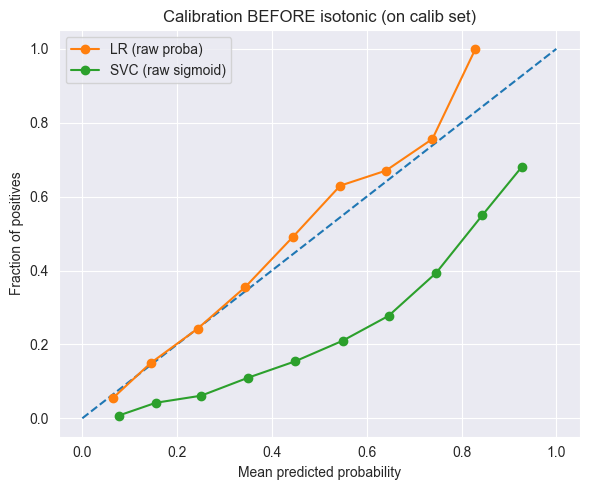

In [62]:
# Строим калибровочные кривые (до калибровки)
def plot_calibration_curve(y_true, probas_dict, n_bins=10, title="Calibration curve"):
    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--")

    for name, p in probas_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="uniform")
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_calibration_curve(
    y_calib,
    {
        "LR (raw proba)": proba_lr_calib,
        "SVC (raw sigmoid)": proba_svc_sigmoid_calib
    },
    n_bins=10,
    title="Calibration BEFORE isotonic (on calib set)"
)

1) LogisticRegression - калибровка в целом неплохая
    - Оранжевая кривая довольно близко к диагонали (идеальная калибровка).
    - Местами есть отклонения (особенно ближе к большим вероятностям), но в среднем LR выдаёт вероятности достаточно “честные”.
    - Резкий скачок около ~0.8–0.85 до 1.0 обычно означает, что в этом бине мало наблюдений (поэтому точка нестабильна).

2) SVC - калибровка плохая
    - Зелёная кривая почти везде ниже диагонали.

In [63]:
# Калибровка isotonic
# --- LR isotonic ---
cal_lr = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_lr),
    method="isotonic",
    cv=None
).fit(X_calib, y_calib)

# --- SVC isotonic ---
cal_svc = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_svc),
    method="isotonic",
    cv=None
).fit(X_calib, y_calib)


In [64]:

# ---------------------------------------------------------
# 6) Функция калибровочные кривые
# ---------------------------------------------------------

def plot_calibration(y_true, probas_dict, n_bins=10, title="Calibration curve"):
    plt.figure(figsize=(6, 5))
    # идеальная калибровка
    plt.plot([0, 1], [0, 1], linestyle="--")

    for name, p in probas_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="uniform")
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [65]:
# ---------------------------------------------------------
# 7) Сравнение по Brier
# ---------------------------------------------------------
def ece_mce(y_true, p, n_bins=10):
    """ECE/MCE по равномерным бинам"""
    y_true = np.asarray(y_true)
    p = np.asarray(p)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(p, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)

    ece = 0.0
    mce = 0.0
    n = len(p)

    for b in range(n_bins):
        mask = idx == b
        if not np.any(mask):
            continue
        bin_prob_mean = p[mask].mean()
        bin_true_mean = y_true[mask].mean()
        gap = abs(bin_true_mean - bin_prob_mean)
        ece += (mask.sum() / n) * gap
        mce = max(mce, gap)
    return ece, mce

def calibration_metrics(y_true, p):
    return {
        "Brier": brier_score_loss(y_true, p),
        "ECE": ece_mce(y_true, p, n_bins=10)[0],
        "MCE": ece_mce(y_true, p, n_bins=10)[1],
        "PR-AUC": average_precision_score(y_true, p)
    }

metrics = {
    "LR raw": calibration_metrics(y_calib, proba_lr_calib),
    "SVC raw sigmoid": calibration_metrics(y_calib, proba_svc_sigmoid_calib),
}

metrics_df = pd.DataFrame(metrics).T.sort_values("Brier")
display(metrics_df)

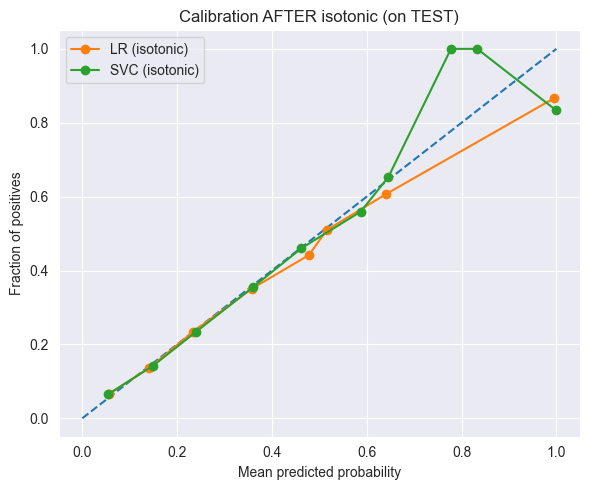

In [66]:
# ---------------------------------------------------------
# 8) Финальная проверка на TEST
# ---------------------------------------------------------
proba_lr_test = cal_lr.predict_proba(X_test)[:, 1]
proba_svc_test = cal_svc.predict_proba(X_test)[:, 1]

ece_lr, mce_lr = ece_mce(y_test, proba_lr_test, n_bins=10)
ece_svc, mce_svc = ece_mce(y_test, proba_svc_test, n_bins=10)

test_df = pd.DataFrame({
    "model": ["LR isotonic", "SVC isotonic"],
    "PR-AUC": [
        average_precision_score(y_test, proba_lr_test),
        average_precision_score(y_test, proba_svc_test),
    ],
    "Brier": [
        brier_score_loss(y_test, proba_lr_test),
        brier_score_loss(y_test, proba_svc_test),
    ],
    "ECE": [ece_lr, ece_svc],
    "MCE": [mce_lr, mce_svc],
}).sort_values("Brier")

display(test_df)

plot_calibration(
    y_test,
    {
        "LR (isotonic)": proba_lr_test,
        "SVC (isotonic)": proba_svc_test,
    },
    n_bins=10,
    title="Calibration AFTER isotonic (on TEST)"
)

- На тестовой выборке оцениваем итоговую калибровку “честно” (данные не использовались при обучении калибратора). Сравниваем модели по Brier/ECE/MCE (качество вероятностей) и PR-AUC (качество ранжирования). Итоговый выбор модели делаем по сочетанию низкого Brier/ECE и приемлемого PR-AUC.
- На `test`-сете калибровочные кривые показывают, насколько хорошо откалиброванные вероятности соответствуют реальной доле кликов в разных диапазонах предсказаний. Отклонения от диагонали в отдельных бинах возможны из-за конечного размера теста и дисбаланса классов, но в целом оцениваем направление улучшений относительно “до калибровки”.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 10. Оценка качества калибровки

#### 10.1 Посчитаем метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравним модели до и после калибровки
- Выведем все метрики в одной таблице.

In [67]:
# --- RAW вероятности на TEST (до калибровки) ---
proba_lr_raw_test = final_lr.predict_proba(X_test)[:, 1]

svc_scores_test = final_svc.decision_function(X_test)
proba_svc_rawsig_test = expit(svc_scores_test)

# --- Итоговая таблица TEST: до/после ---
test_metrics = {
    "LR raw": calibration_metrics(y_test, proba_lr_raw_test),
    "LR isotonic": calibration_metrics(y_test, proba_lr_test),
    "SVC raw sigmoid": calibration_metrics(y_test, proba_svc_rawsig_test),
    "SVC isotonic": calibration_metrics(y_test, proba_svc_test),
}

test_metrics_df = pd.DataFrame(test_metrics).T.sort_values("Brier")
display(test_metrics_df)

- **SVC до калибровки (raw sigmoid)** показывает плохое качество вероятностей: высокий Brier (~0.203) и большие ошибки калибровки (ECE~0.262, MCE~0.392). Это ожидаемо, так как `decision_function` не является вероятностью.
- **SVC после isotonic-калибровки** заметно улучшился по вероятностным метрикам: Brier снизился до ~0.126, ECE - до ~0.008. Значит, изотоническая калибровка успешно "приблизила" вероятности SVC к реальным частотам клика.
- **LogisticRegression** уже имеет хорошую калибровку: на TEST у неё лучший Brier (~0.126) и низкий ECE (~0.004) без дополнительной калибровки. После isotonic метрики не улучшились и PR-AUC снизился, поэтому для LR калибровка оказалась нецелесообразной.
- В целом калибровка улучшила качество **вероятностей** для SVC, но может слегка снижать PR-AUC, так как она оптимизирует соответствие вероятностей, а не ранжирование.

Практический итог:
- Если приоритет - лучшее ранжирование (PR-AUC), можно оставить LR raw.
- Если приоритет - адекватные вероятности (калибровка), то:
    - для `SVC` калибровка обязательна (сырой sigmoid сильно хуже),
    - для `LR` калибровка на этом сплите не дала выигрыша по `Brier`, поэтому `LR` можно оставить без калибровки.

## 11. Финальный отчёт и выводы
- Сведём все результаты в таблицу

In [68]:
# =========================
# 11.1 Итоговая сводная таблица
# =========================

baseline_summary = (
    report_df
    .rename(columns={
        "name": "model",
        "PR-AUC_mean": "PR-AUC_CV",
        "PR-AUC_std": "PR-AUC_CV_std",
        "Precision_mean": "Precision_CV",
        "Recall_mean": "Recall_CV",
        "F1_mean": "F1_CV"
    })
    [["model", "PR-AUC_CV", "PR-AUC_CV_std", "Precision_CV", "Recall_CV", "F1_CV"]]
)

# Приведём имена к единому стилю
name_map = {
    "DummyClassifier (most_frequent)": "Dummy (most_frequent)",
    "LogisticRegression": "LR baseline",
    "SVS (linear, probability=False)": "SVC baseline (linear)"
}
baseline_summary["model"] = baseline_summary["model"].replace(name_map)

test_summary = (
    test_metrics_df
    .reset_index()
    .rename(columns={
        "index": "model",
        "PR-AUC": "PR-AUC_TEST",
        "Brier": "Brier_TEST",
        "ECE": "ECE_TEST",
        "MCE": "MCE_TEST",
    })
)

# Чуть переименуем строки
test_name_map = {
    "LR raw": "LR raw",
    "LR isotonic": "LR isotonic",
    "SVC raw sigmoid": "SVC raw sigmoid",
    "SVC isotonic": "SVC isotonic",
}
test_summary["model"] = test_summary["model"].replace(test_name_map)

# 3) Склеиваем: baseline (CV) + test (калибровка)
final_report = pd.concat([baseline_summary, test_summary], ignore_index=True, sort=False)

# 4) Упорядочим строки
order = [
    "Dummy (most_frequent)",
    "LR baseline",
    "SVC baseline (linear)",
    "LR raw",
    "LR isotonic",
    "SVC raw sigmoid",
    "SVC isotonic",
]

final_report["model"] = pd.Categorical(final_report["model"], categories=order, ordered=True)
final_report = final_report.sort_values("model").reset_index(drop=True)

display(final_report)

In [69]:
display(coef_df.head(5))

- Первые 3 строки - результаты кросс-валидации (baseline) -> поэтому TEST-метрики = NaN.
- Нижние строки - результаты на TEST (до/после калибровки) -> поэтому CV-метрики = NaN.
- Такое разделение сделано специально, чтобы не путать оценку качества модели (CV) и оценку калибровки/обобщения (TEST).

# Итоговый вывод по проекту

## 1) Постановка задачи и данные
- Решалась задача **бинарной классификации CTR**: предсказать вероятность клика `click` по данным показов рекламы.
- Основная метрика качества: **PR-AUC** (Average Precision), дополнительные: **LogLoss / Brier / ECE / MCE**, а также Precision/Recall/F1 при необходимости.

## 2) EDA и первичная очистка данных
- Проверены:
  - распределение целевой переменной (класс “клик” является миноритарным),
  - пропуски (явных NaN не обнаружено),
  - “заглушки” в категориальных признаках (unknown/na/none и т.п.) - существенных не найдено,
  - потенциальные псевдо-пропуски в числовых признаках (например, `-1` и большие доли нулей) - выявлены и проанализированы.
- Выполнен первичный анализ категориальных признаков:
  - рассчитана **кардинальность** (число уникальных значений) и распределения,
  - визуализированы частоты значений в разрезе групп кардинальности (чтобы графики оставались читаемыми),
  - выявлены признаки с “аномальным” распределением (например, доминирующее значение в `device_id`), из-за чего часть идентификаторов была исключена.
- Сформирован итоговый датафрейм для моделирования `df_eda_final` и подготовлены признаки времени:
  - `hour` преобразован в datetime,
  - добавлены `hour_of_day` и `dayofweek`.

## 3) Корреляционный анализ и сокращение признаков
- Для оценки связи признаков с целевой использовалась **PhiK-корреляция** (подходит для смеси числовых/категориальных признаков).
- Построены heatmap/матрицы PhiK:
  - выделены признаки с наибольшей связью с `click` (например, **C14, C17**, часть **ml_features**, доменные признаки и др.),
  - проверены сильные взаимосвязи “фича-фича” (для возможного удаления избыточных признаков).

## 4) Разделение данных на выборки
- Выполнено разделение на **train/test = 80/20** со **stratify по `click`**, чтобы сохранить долю кликов в каждой выборке.
- Проверено, что распределение `click` в train/test практически совпадает с исходным.

## 5) Предобработка: пайплайны и защита от утечек
- Собран единый `preprocessor` через `ColumnTransformer` + `Pipeline`:
  - **числовые**: `SimpleImputer(strategy="median")` + `StandardScaler`,
  - **категориальные**: `SimpleImputer(strategy="most_frequent")`,
  - кодирование категорий:
    - **OneHotEncoding** для признаков с низкой кардинальностью,
    - **TargetEncoder** для высококардинальных (порог кардинальности выбран как `> 25`).
- Важно: весь препроцессинг обучался **только внутри CV/на train**, тестовая выборка не использовалась до финальной оценки.

## 6) Отбор признаков
- Реализован отбор признаков без утечек (внутри пайплайна и CV):
  - `VarianceThreshold` для удаления признаков с нулевой вариативностью,
  - фильтрация `SelectKBest(mutual_info_classif)` с подбором `k` через `GridSearchCV`,
  - wrapper-метод `RFE(LogisticRegression)` (также с подбором числа признаков через CV).
- По результатам сравнения выбрана итоговая схема отбора признаков для дальнейших шагов.

## 7) Базовые модели и сравнение
- Обучены и сравненены модели на 5-fold CV:
  - **DummyClassifier** как baseline “нижняя планка”,
  - **LogisticRegression** (линейная интерпретируемая модель),
  - **SVC(kernel="linear", probability=False)** (вероятности отдельно через калибровку).
- Оценка проводилась по **PR-AUC**, при необходимости добавлялись Precision/Recall/F1 и учитывалась проблема дисбаланса (например, через `class_weight="balanced"`).

## 8) Подбор гиперпараметров (GridSearchCV)
- Для LogisticRegression и SVC выполнен **GridSearchCV** со scoring=`average_precision`:
  - для LR подбирался `C`, `class_weight` и регуляризация (с учётом актуальных предупреждений sklearn),
  - для SVC подбирался `C` и `class_weight`.
- Сформированы таблицы **top-10 конфигураций** и выбраны лучшие параметры.

## 9) Финальная модель и тестирование
- Собрана финальная модель (пайплайн: `preprocess -> vt -> select -> model`) с лучшими параметрами.
- На **test** посчитаны ключевые метрики (PR-AUC и Brier), тест не использовался раньше финального шага.

## 10) Калибровка вероятностей
- Выделена отдельная **calibration**-выборка из train (train_fit + calib), чтобы избежать утечки при калибровке.
- До калибровки:
  - LogisticRegression: использованы `predict_proba`,
  - SVC: использованы `decision_function` + “сырая” сигмоида `expit` для получения значений в [0,1].
- Применена калибровка **CalibratedClassifierCV(method="isotonic")**.
- Выполнено сравнение **до/после** по метрикам: **Brier, ECE, MCE**, а также визуализация калибровочных кривых.

## 11) Итоговая оценка качества калибровки
- Сведены метрики на calib/test:
  - PR-AUC (качество ранжирования),
  - Brier (качество вероятностей),
  - ECE/MCE (калибровка).
- Сделан вывод, что калибровка может улучшать калибровочные метрики, но не обязана повышать PR-AUC (это нормально).

## 12) Итоговые выводы и рекомендации
- Линейные модели **существенно лучше DummyClassifier**, значит данные содержат предсказательный сигнал.
- Наибольший вклад в прогноз вносят признаки семейства **C14/C17** и часть **ml_feature**, а также контекстные признаки (время/устройство/домен) - по итогам корреляций и весов линейной модели.
- Модель в текущем виде **формально готова** к использованию как базовое решение: есть пайплайн, есть отбор признаков, есть оценка и калибровка.
- Рекомендации на улучшение:
  - добавить новые признаки (время, агрегаты, преобразования числовых),
  - тюнинг кодировщиков (TargetEncoder и альтернативы),
  - сравнить isotonic vs sigmoid,
  - при наличии временного смысла данных - валидироваться time-based split.

## 12. Сохранение модели для продакшена

### 12.1 Сохраним артефакты

Сохраним:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверим работоспособность кода

- Загрузим сохранённые артефакты.
- Сделаем предсказания на новых данных.
- Убедимся, что результаты совпадают.

In [116]:
# ============================================================
# 12. Сохранение артефактов + проверка загрузки
# ============================================================
import os
import joblib

ART_DIR = "artifacts"
os.makedirs(ART_DIR, exist_ok=True)

# 1) сохраняем отдельно
joblib.dump(preprocessor, f"{ART_DIR}/preprocessor.joblib")
joblib.dump(cal_lr, f"{ART_DIR}/calibrated_model.joblib")
joblib.dump(selected_features_list, f"{ART_DIR}/selected_features_list.joblib")

# 2) production_model = calibrated_model (без preprocess!)
production_model = cal_lr
joblib.dump(production_model, f"{ART_DIR}/production_model.joblib")

print("Артефакты сохранены:", os.listdir(ART_DIR))

# ----------------------------
# Проверка загрузки + совпадение
# ----------------------------
preprocessor_loaded = joblib.load(f"{ART_DIR}/preprocessor.joblib")
calibrated_model_loaded = joblib.load(f"{ART_DIR}/calibrated_model.joblib")
selected_features_loaded = joblib.load(f"{ART_DIR}/selected_features_list.joblib")
production_model_loaded = joblib.load(f"{ART_DIR}/production_model.joblib")

print("Загружено:")
print("preprocessor_loaded:", type(preprocessor_loaded))
print("calibrated_model_loaded:", type(calibrated_model_loaded))
print("len(selected_features_loaded):", len(selected_features_loaded))
print("production_model_loaded:", type(production_model_loaded))

X_new = X_test.sample(300, random_state=42)

p1 = production_model.predict_proba(X_new)[:, 1]
p2 = production_model_loaded.predict_proba(X_new)[:, 1]

same = np.allclose(p1, p2, rtol=1e-12, atol=1e-12)
print("\nСовпадают ли вероятности до/после сохранения?:", same)
print("max|diff| =", np.max(np.abs(p1 - p2)))

check_df = pd.DataFrame({
    "proba_before": p1[:10],
    "proba_after": p2[:10],
    "abs_diff": np.abs(p1[:10] - p2[:10])
})
display(check_df)

артефакты успешно сохранены и загружены; production_model воспроизводим - вероятности до/после сохранения полностью совпали (max|diff| = 0.0), значит пайплайн готов к использованию и переносим в прод.